# 07 — Severity Modelling

## Main question

**Among incidents with reported aircraft damage, can damage severity be modelled reliably enough to retain this secondary component for downstream simulation?**

This notebook implements the project's second-stage severity model. It is **conditional on a wildlife strike already being reported and on `INDICATED_DAMAGE = 1`**. It does not predict whether a strike will occur and it does not replace the primary binary damage-probability system developed in Notebooks 05–06.

The notebook follows the same modelling principles used in Notebook 05:

- scenario-eligible predictors only;
- explicit leakage checks;
- an expanding chronological cross-validation design inside 1990–2018;
- a majority-class baseline;
- Logistic Regression, Random Forest, and XGBoost candidates;
- hyperparameter tuning without touching the final test;
- conventional classification metrics **and** probability-quality metrics;
- reproducible seeds and persistent candidate outputs.

Severity adds several requirements:

1. `M?` is retained as its own class because the FAA documentation defines it as **undetermined level**, not minor damage.
2. `D` (Destroyed) is merged with `S` (Substantial) **for modelling only** because the Destroyed class is too sparse for stable independent estimation and validation.
3. The resulting target is a **nominal three-class outcome**: `M`, `M?`, and `S+D`. `M?` is not placed on an ordinal scale.
4. **Macro-F1** is the primary hyperparameter-selection metric so that minority classes cannot be hidden by the dominant class.
5. Precision, recall, and F1 for the `S+D` class are always reported separately.
6. Class weighting is **tested rather than imposed**. Logistic Regression and Random Forest use their native `class_weight` support; multiclass XGBoost uses training-row `sample_weight`.
7. Calibration and temporal validation are required before severity can be passed to simulation.
8. The notebook ends with an explicit **RETAIN / SIMPLIFY / DROP** decision gate. A decision not to use severity in simulation is an acceptable scientific result.



## 1. Methodological decisions and academic justification

### 1.1 FAA severity definitions

The original FAA data dictionary identifies the damage field as a level selected by the Database Manager and provides ICAO-based definitions:

- **M — Minor:** the aircraft can be rendered airworthy through simple repairs or replacements without an extensive inspection.
- **M? — Undetermined level:** the aircraft was damaged, but the available details are insufficient to determine the extent.
- **S — Substantial:** damage or structural failure adversely affects structural strength, performance, or flight characteristics and normally requires major repair or replacement of the affected component.
- **D — Destroyed:** the damage makes restoration to an airworthy condition inadvisable.

Because `M?` represents **uncertainty about severity**, it is not a midpoint between `M` and `S`, and it must not be silently recoded as Minor.

### 1.2 Why `D` is merged with `S` for modelling

Destroyed and Substantial remain **distinct aviation-damage concepts**. Their merger here does **not** claim that they have equal physical, operational, financial, or safety consequences.

The modelling dataset contains very few Destroyed observations relative to the other severity categories. A class with only a handful of observations in validation or final testing would yield extremely unstable class-specific recall, precision, calibration, and probability estimates. Therefore, Destroyed observations are preserved in the raw target but combined with Substantial as a **severe modelling category (`S+D`)**.

This is a statistical-support decision, not a redefinition of aviation severity. It also avoids discarding Destroyed incidents entirely and keeps them represented at the severe end of the modelled outcome.

### 1.3 Why Macro-F1 is the primary tuning metric

Severity is an imbalanced multiclass problem. Overall accuracy and weighted metrics can be dominated by common classes. Macro-F1 calculates F1 separately for each class and then gives each class equal influence in the average. It is therefore used as the primary tuning criterion.

Macro-F1 is **not used alone**. The notebook also reports:

- class-specific precision, recall, and F1;
- macro precision and macro recall;
- weighted F1;
- balanced accuracy;
- confusion matrices;
- multiclass log loss;
- multiclass Brier score;
- macro one-vs-rest average precision;
- macro one-vs-rest ROC-AUC where all classes are evaluable.

The `S+D` precision, recall, and F1 are explicitly retained in every important comparison table.

### 1.4 Class weighting

Imbalanced-learning literature supports cost-sensitive/class-weighted learning as a standard response to unequal class frequencies, but probability-oriented research also cautions that imbalance corrections can distort calibration when imposed without validation.

For that reason, weighting is a **hyperparameter choice**:

- Logistic Regression: `class_weight ∈ {None, "balanced"}`;
- Random Forest: `class_weight ∈ {None, "balanced_subsample"}`;
- XGBoost: `sample_weight_mode ∈ {"none", "balanced"}` using fold-specific balanced observation weights.

No SMOTE or synthetic oversampling is used in the primary experiment. This keeps the workflow simpler, avoids generating synthetic combinations of scenario categories, and lets calibration be evaluated honestly afterward.

### References supporting these choices

- FAA Wildlife Strike Database data dictionary / field definitions; severity definitions reproduce the ICAO-based categories included in the project source dictionary.
- He, H., & Garcia, E. A. (2009). *Learning from Imbalanced Data*. IEEE Transactions on Knowledge and Data Engineering, 21(9), 1263–1284.
- Pedregosa, F., et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825–2830.
- Chen, T., & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. Proceedings of KDD.
- van den Goorbergh, R., van Smeden, M., Timmerman, D., & Van Calster, B. (2022/2023). Work examining how class-imbalance corrections can affect risk-prediction calibration. This motivates **testing** weighting rather than assuming it must improve the final probability system.

## 2. Environment and reproducibility

`xgboost` is used to retain the same candidate-model family as Notebook 05. If it is unavailable in the active environment, install it once and rerun the imports.

In [1]:
# Uncomment only if xgboost is missing in the active environment.
# %pip install -q xgboost

In [2]:
from pathlib import Path
import json
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import ParameterGrid
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss,
    average_precision_score,
    roc_auc_score,
)

from xgboost import XGBClassifier

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 200)

SEED = 42
np.random.seed(SEED)

CLASS_LABELS = ["M", "M?", "S+D"]
LABEL_TO_INT = {label: i for i, label in enumerate(CLASS_LABELS)}
INT_TO_LABEL = {i: label for label, i in LABEL_TO_INT.items()}
N_CLASSES = len(CLASS_LABELS)

print("Seed:", SEED)
print("Severity classes:", CLASS_LABELS)

Seed: 42
Severity classes: ['M', 'M?', 'S+D']


## 3. Portable project paths

The notebook searches upward for a repository containing `data`. In the final repository, the canonical source should be:

`data/processed/faa_strikes_analytical.csv`

Persistent outputs are separated into:

- `outputs/07_severity_modelling/` — tables, predictions, CV results, calibration evidence;
- `models/candidates/07_severity_modelling/` — fitted severity candidates;
- `models/final/07_severity_modelling/` — only a severity artifact that passes the final decision gate.

This preserves the same candidates-versus-final distinction used by the modelling workflow.

In [ ]:
ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "data").exists() or (candidate / "models").exists():
        ROOT = candidate
        break

DATA_CANDIDATES = [
    ROOT / "data" / "processed" / "faa_strikes_analytical.csv",
    ROOT / "data" / "processed" / "faa_strikes_analytical(3).csv",
    Path("/mnt/data/faa_strikes_analytical(3).csv"),
]

DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not locate faa_strikes_analytical.csv. "
        "Update DATA_CANDIDATES to point to the canonical Notebook 02 output."
    )

FEATURE_LIST_CANDIDATES = [
    ROOT / "outputs" / "feature_lists.json",
    ROOT / "data" / "processed" / "feature_lists.json",
    ROOT / "docs" / "feature_lists.json",
]
FEATURE_LIST_PATH = next((p for p in FEATURE_LIST_CANDIDATES if p.exists()), None)

OUTPUT_DIR = ROOT / "outputs" / "07_severity_modelling"
CANDIDATE_MODEL_DIR = ROOT / "models" / "candidates" / "07_severity_modelling"
FINAL_MODEL_DIR = ROOT / "models" / "final" / "07_severity_modelling"

for folder in [OUTPUT_DIR, CANDIDATE_MODEL_DIR, FINAL_MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("DATA_PATH:", DATA_PATH)
print("FEATURE_LIST_PATH:", FEATURE_LIST_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("CANDIDATE_MODEL_DIR:", CANDIDATE_MODEL_DIR)
print("FINAL_MODEL_DIR:", FINAL_MODEL_DIR)

ROOT: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis
DATA_PATH: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\data\processed\faa_strikes_analytical.csv
FEATURE_LIST_PATH: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\docs\feature_lists.json
OUTPUT_DIR: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\outputs\07_severity_modeling
CANDIDATE_MODEL_DIR: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\models\candidates
FINAL_MODEL_DIR: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\models\final


## 4. Load the canonical analytical dataset

Notebook 07 consumes the cleaned analytical dataset rather than redefining cleaning rules. The raw `DAMAGE_LEVEL` field is retained for auditing, while a new modelling target is created locally.

In [4]:
df = pd.read_csv(DATA_PATH, low_memory=False)

required_columns = {
    "INDICATED_DAMAGE", "DAMAGE_LEVEL", "INCIDENT_YEAR", "INDEX_NR"
}
missing_required = sorted(required_columns - set(df.columns))
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
print(
    "Year coverage:",
    int(df["INCIDENT_YEAR"].min()),
    "to",
    int(df["INCIDENT_YEAR"].max()),
)

Rows: 319,107
Columns: 150
Year coverage: 1990 to 2024


## 5. Severity feasibility audit before modelling

The checklist requires the severity component to justify its own feasibility before any model is trained.

This section checks:

- restriction to damaged incidents;
- raw severity classes and missingness;
- consistency with the binary damage target;
- class counts by chronological split;
- the amount of support available for `D`;
- whether the `M?` frequency changes strongly over time.

A sharp temporal change in `M?` must be interpreted as a possible reporting/completeness shift. It must **not** be interpreted as an ordered movement toward more or less physical damage.

In [5]:
damaged = df.loc[df["INDICATED_DAMAGE"].eq(1)].copy()

severity_audit = pd.DataFrame({
    "measure": [
        "All analytical incidents",
        "Damaged incidents",
        "Damaged incidents with missing DAMAGE_LEVEL",
        "Damaged incidents with non-missing DAMAGE_LEVEL",
    ],
    "count": [
        len(df),
        len(damaged),
        int(damaged["DAMAGE_LEVEL"].isna().sum()),
        int(damaged["DAMAGE_LEVEL"].notna().sum()),
    ],
})
display(severity_audit)

raw_class_counts = (
    damaged["DAMAGE_LEVEL"]
    .value_counts(dropna=False)
    .rename_axis("DAMAGE_LEVEL")
    .reset_index(name="count")
)
raw_class_counts["proportion"] = raw_class_counts["count"] / len(damaged)
display(raw_class_counts)

raw_class_counts.to_csv(
    OUTPUT_DIR / "severity_raw_class_counts.csv", index=False
)

,measure,count
0,All analytical incidents,319107
1,Damaged incidents,20908
2,Damaged incidents with missing DAMAGE_LEVEL,0
3,Damaged incidents with non-missing DAMAGE_LEVEL,20908


,DAMAGE_LEVEL,count,proportion
0,M,8657,0.414052
1,M?,7818,0.373924
2,S,4344,0.207767
3,D,89,0.004257


### Interpretation — raw severity feasibility

The analytical dataset contains 20,908 damaged incidents, and all of them have a recorded `DAMAGE_LEVEL`; therefore, no damaged observations are lost because of missing severity labels. Minor damage (`M`) is the largest raw category with 8,657 cases (41.4%), followed by undetermined severity (`M?`) with 7,818 (37.4%), Substantial damage (`S`) with 4,344 (20.8%), and Destroyed (`D`) with only 89 cases (0.43%). The `D` category is therefore too sparse to support reliable independent training, calibration, and later-period validation. In accordance with the modelling decision established above, `D` is retained in the original data but combined with `S` into the `S+D` severe modelling class. This aggregation is based on statistical support and does not imply that Substantial and Destroyed damage are operationally equivalent. The large number of `M?` cases is also retained as a separate outcome because it represents an undetermined damage level rather than Minor damage.

In [6]:
# Preserve the raw label and create the modelling label.
damaged["DAMAGE_LEVEL_RAW_MODEL_AUDIT"] = damaged["DAMAGE_LEVEL"]

def map_severity_for_model(value):
    if value == "M":
        return "M"
    if value == "M?":
        return "M?"
    if value in {"S", "D"}:
        return "S+D"
    return np.nan

damaged["SEVERITY_MODEL"] = damaged["DAMAGE_LEVEL"].map(map_severity_for_model)

# Only records with one of the documented damaged severity codes can enter the model.
severity_df = damaged.loc[damaged["SEVERITY_MODEL"].notna()].copy()
severity_df["SEVERITY_TARGET"] = severity_df["SEVERITY_MODEL"].map(LABEL_TO_INT).astype(int)

print("Rows retained for severity modelling:", f"{len(severity_df):,}")
display(
    severity_df[["DAMAGE_LEVEL", "SEVERITY_MODEL"]]
    .value_counts()
    .rename("count")
    .reset_index()
)

assert set(severity_df["DAMAGE_LEVEL"].unique()).issubset({"M", "M?", "S", "D"})
assert set(severity_df["SEVERITY_MODEL"].unique()) == set(CLASS_LABELS)

Rows retained for severity modelling: 20,908


,DAMAGE_LEVEL,SEVERITY_MODEL,count
0,M,M,8657
1,M?,M?,7818
2,S,S+D,4344
3,D,S+D,89


### Decision recorded in the notebook: `D → S+D`

`D` is merged with `S` **only in `SEVERITY_MODEL`**. The original `DAMAGE_LEVEL` and the copied audit field remain unchanged.

The decision is justified by support, not semantics. Destroyed damage remains more severe than Substantial damage under the FAA/ICAO definitions. However, reliable standalone estimation requires enough observations in training **and** enough observations in later validation/test periods to estimate errors and calibration with tolerable stability. When only a very small number of Destroyed cases occur in those periods, a separate `D` class would produce fragile metrics.

Combining `D` with `S` retains Destroyed incidents in the severe outcome while avoiding a misleading appearance of precision.

## 6. Locked chronological partitions

The same periods used in Notebooks 05–06 are retained:

- **Training / tuning:** 1990–2018
- **Validation / model-selection and calibration development:** 2019–2021
- **Locked final test:** 2022–2024

The final test must remain unopened until the model family, hyperparameters, calibration method, and decision criteria have been selected from earlier periods.

In [7]:
train_mask = severity_df["INCIDENT_YEAR"].between(1990, 2018)
validation_mask = severity_df["INCIDENT_YEAR"].between(2019, 2021)
test_mask = severity_df["INCIDENT_YEAR"].between(2022, 2024)

split_summary = []
for split_name, mask in [
    ("train_1990_2018", train_mask),
    ("validation_2019_2021", validation_mask),
    ("test_2022_2024_LOCKED", test_mask),
]:
    subset = severity_df.loc[mask]
    counts = subset["SEVERITY_MODEL"].value_counts()
    row = {
        "split": split_name,
        "rows": len(subset),
    }
    for label in CLASS_LABELS:
        row[f"count_{label}"] = int(counts.get(label, 0))
        row[f"rate_{label}"] = float(counts.get(label, 0) / len(subset)) if len(subset) else np.nan
    split_summary.append(row)

split_summary = pd.DataFrame(split_summary)
display(split_summary)
split_summary.to_csv(OUTPUT_DIR / "severity_split_class_counts.csv", index=False)

,split,rows,count_M,rate_M,count_M?,rate_M?,count_S+D,rate_S+D
0,train_1990_2018,16737,8178,0.488618,4407,0.263309,4152,0.248073
1,validation_2019_2021,1925,209,0.108571,1587,0.824416,129,0.067013
2,test_2022_2024_LOCKED,2246,270,0.120214,1824,0.812110,152,0.067676


### Interpretation — temporal class structure

The severity distribution changes substantially across the chronological partitions. In the 1990–2018 training period, `M` is the largest class with 8,178 of 16,737 cases (48.9%), while `M?` accounts for 4,407 (26.3%) and `S+D` for 4,152 (24.8%). In contrast, `M?` becomes dominant in both later periods: it represents 1,587 of 1,925 validation incidents (82.4%) in 2019–2021 and 1,824 of 2,246 final-test incidents (81.2%) in 2022–2024. Over the same periods, `M` falls to approximately 10.9% and 12.0%, while `S+D` falls to approximately 6.7% in both periods. This represents a major temporal distribution shift in the recorded severity outcome. Because `M?` means that the level of damage could not be determined, this change should not be interpreted as evidence that physical aircraft damage became less severe. Instead, it indicates a substantial change in severity reporting or completeness across time and creates an important generalization challenge for models trained mainly on earlier records.

## 7. Canonical feature lists and leakage protection

Severity is conditional on damage, but that does **not** make post-event damage information acceptable as predictors.

The model uses the same scenario-eligible predictors approved for Notebook 05. Fields describing the realized damage, component damage, injuries/fatalities, repair costs, operational consequences, or administrative/reporting information remain excluded.

This is essential because Notebook 10 can only ask the severity model about inputs known in the simulated strike scenario.

In [7]:
fallback_feature_lists = {
    "core_features": [
        "SEASON", "MONTH_SIN", "MONTH_COS", "WILDLIFE_TYPE", "SIZE",
        "NUM_STRUCK", "AC_CLASS", "AC_MASS_GROUP", "TYPE_ENG",
        "NUM_ENGS", "WARNED"
    ],
    "extended_features": [
        "SEASON", "MONTH_SIN", "MONTH_COS", "WILDLIFE_TYPE", "SIZE",
        "NUM_STRUCK", "AC_CLASS", "AC_MASS_GROUP", "TYPE_ENG",
        "NUM_ENGS", "WARNED", "PHASE_OF_FLIGHT", "HEIGHT", "SPEED",
        "TIME_OF_DAY", "SKY", "PRECIPITATION", "STATE", "FAAREGION"
    ],
    "airport_aware_features": [
        "SEASON", "MONTH_SIN", "MONTH_COS", "WILDLIFE_TYPE", "SIZE",
        "NUM_STRUCK", "AC_CLASS", "AC_MASS_GROUP", "TYPE_ENG",
        "NUM_ENGS", "WARNED", "PHASE_OF_FLIGHT", "HEIGHT", "SPEED",
        "TIME_OF_DAY", "SKY", "PRECIPITATION", "STATE", "FAAREGION",
        "AIRPORT_ID"
    ],
    "seed": SEED,
}

if FEATURE_LIST_PATH is not None:
    with open(FEATURE_LIST_PATH, "r", encoding="utf-8") as f:
        feature_lists = json.load(f)
else:
    feature_lists = fallback_feature_lists.copy()
    warnings.warn(
        "feature_lists.json was not found. The approved Notebook 02/05 fallback "
        "is being used. Restore the canonical JSON artifact before final submission."
    )

EXTENDED_FEATURES = [
    c for c in feature_lists["extended_features"] if c in severity_df.columns
]
AIRPORT_AWARE_FEATURES = [
    c for c in feature_lists["airport_aware_features"] if c in severity_df.columns
]

FEATURE_SETS = {
    "extended_geographic": EXTENDED_FEATURES,
    "airport_aware": AIRPORT_AWARE_FEATURES,
}

forbidden_predictors = {
    "DAMAGE_LEVEL", "DAMAGE_LEVEL_RAW", "DAMAGE_LEVEL_RAW_MODEL_AUDIT",
    "SEVERITY_MODEL", "SEVERITY_TARGET",
    "INDICATED_DAMAGE",
    "EFFECT", "EFFECT_OTHER", "AOS",
    "COST_REPAIRS", "COST_OTHER",
    "COST_REPAIRS_INFL_ADJ", "COST_OTHER_INFL_ADJ",
    "NR_INJURIES", "NR_FATALITIES",
    "INCIDENT_YEAR", "TEMPORAL_SPLIT", "INDEX_NR",
    "TARGET_CONFLICT_FLAG", "SEVERITY_ELIGIBLE_FLAG",
}
forbidden_predictors |= {
    c for c in severity_df.columns if c.startswith(("DAM_", "STR_", "ING_"))
}

for set_name, features in FEATURE_SETS.items():
    leaked = sorted(set(features) & forbidden_predictors)
    assert not leaked, f"{set_name} contains forbidden predictors: {leaked}"

feature_set_table = pd.DataFrame([
    {
        "feature_set": name,
        "feature_count": len(features),
        "includes_airport_id": "AIRPORT_ID" in features,
        "leakage_check": "PASS",
    }
    for name, features in FEATURE_SETS.items()
])
display(feature_set_table)

print("Leakage assertions passed.")

,feature_set,feature_count,includes_airport_id,leakage_check
0,extended_geographic,19,False,PASS
1,airport_aware,20,True,PASS


Leakage assertions passed.


## 8. Training-only preprocessing

Preprocessing mirrors Notebook 05:

- numerical values: training-fold median imputation;
- Logistic Regression: numerical scaling;
- `NUM_STRUCK`: ordered encoding of documented count ranges;
- nominal categories: explicit missing label plus sparse one-hot encoding;
- rare categories: training-fitted grouping through `min_frequency`.

The use of sparse encoding is particularly useful for Random Forest runtime because the airport-aware feature set can produce many one-hot columns. No learned preprocessing is fitted globally.

In [8]:
NUM_STRUCK_ORDER = [["1", "2–10", "11–100", "More than 100"]]

def make_preprocessor(features, scale_numeric=False, min_category_frequency=50):
    ordinal_features = [c for c in ["NUM_STRUCK"] if c in features]

    numeric_features = [
        c for c in features
        if c != "NUM_STRUCK" and pd.api.types.is_numeric_dtype(severity_df[c])
    ]

    categorical_features = [
        c for c in features
        if c not in ordinal_features + numeric_features
    ]

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        # with_mean=False preserves sparse compatibility after column concatenation.
        numeric_steps.append(("scaler", StandardScaler(with_mean=False)))

    transformers = []

    if numeric_features:
        transformers.append((
            "numeric",
            Pipeline(numeric_steps),
            numeric_features,
        ))

    if ordinal_features:
        transformers.append((
            "num_struck_ordinal",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ordinal", OrdinalEncoder(
                    categories=NUM_STRUCK_ORDER,
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                    encoded_missing_value=-1,
                )),
            ]),
            ordinal_features,
        ))

    if categorical_features:
        transformers.append((
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(
                    strategy="constant",
                    fill_value="Not reported",
                )),
                ("onehot", OneHotEncoder(
                    handle_unknown="infrequent_if_exist",
                    min_frequency=min_category_frequency,
                    sparse_output=True,
                )),
            ]),
            categorical_features,
        ))

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        sparse_threshold=1.0,
        verbose_feature_names_out=True,
    )

## 9. Expanding chronological cross-validation inside 1990–2018

The fold structure is intentionally the same as Notebook 05:

| Fold | Training years | Validation years |
|---|---|---|
| 1 | 1990–2003 | 2004–2006 |
| 2 | 1990–2006 | 2007–2009 |
| 3 | 1990–2009 | 2010–2012 |
| 4 | 1990–2012 | 2013–2015 |
| 5 | 1990–2015 | 2016–2018 |

This allows hyperparameter CV while preserving temporal order. The 2019–2021 validation period and 2022–2024 final test are outside the tuning folds.

In [10]:
CV_FOLDS = [
    {"fold": 1, "train_years": range(1990, 2004), "validation_years": range(2004, 2007)},
    {"fold": 2, "train_years": range(1990, 2007), "validation_years": range(2007, 2010)},
    {"fold": 3, "train_years": range(1990, 2010), "validation_years": range(2010, 2013)},
    {"fold": 4, "train_years": range(1990, 2013), "validation_years": range(2013, 2016)},
    {"fold": 5, "train_years": range(1990, 2016), "validation_years": range(2016, 2019)},
]

cv_summary = []
for spec in CV_FOLDS:
    fold_train = severity_df.loc[
        train_mask & severity_df["INCIDENT_YEAR"].isin(spec["train_years"])
    ]
    fold_val = severity_df.loc[
        train_mask & severity_df["INCIDENT_YEAR"].isin(spec["validation_years"])
    ]

    row = {
        "fold": spec["fold"],
        "train_start": min(spec["train_years"]),
        "train_end": max(spec["train_years"]),
        "validation_start": min(spec["validation_years"]),
        "validation_end": max(spec["validation_years"]),
        "train_rows": len(fold_train),
        "validation_rows": len(fold_val),
    }

    for label in CLASS_LABELS:
        row[f"train_{label}"] = int((fold_train["SEVERITY_MODEL"] == label).sum())
        row[f"validation_{label}"] = int((fold_val["SEVERITY_MODEL"] == label).sum())

    cv_summary.append(row)

cv_summary = pd.DataFrame(cv_summary)
display(cv_summary)
cv_summary.to_csv(OUTPUT_DIR / "severity_chronological_cv_design.csv", index=False)

# Fail early if any fold cannot evaluate all three classes.
for label in CLASS_LABELS:
    assert (cv_summary[f"train_{label}"] > 0).all(), f"Training fold lacks {label}"
    assert (cv_summary[f"validation_{label}"] > 0).all(), f"Validation fold lacks {label}"

,fold,train_start,train_end,validation_start,validation_end,train_rows,validation_rows,train_M,validation_M,train_M?,validation_M?,train_S+D,validation_S+D
0,1,1990,2003,2004,2006,7577,1843,4099,917,1328,462,2150,464
1,2,1990,2006,2007,2009,9420,1703,5016,843,1790,498,2614,362
2,3,1990,2009,2010,2012,11123,1778,5859,1014,2288,282,2976,482
3,4,1990,2012,2013,2015,12901,1832,6873,880,2570,435,3458,517
4,5,1990,2015,2016,2018,14733,2004,7753,425,3005,1402,3975,177


## 10. Candidate models

Four references are retained:

1. **Dummy majority baseline** — establishes no-skill classification behavior.
2. **Multiclass Logistic Regression** — linear/interpretable baseline.
3. **Random Forest** — nonlinear bagged-tree candidate.
4. **XGBoost** — nonlinear gradient-boosting candidate.

Random Forest tuning is separated into its own cell because it was the most computationally expensive family in Notebook 05. This severity dataset is much smaller than the full binary-damage dataset, and two implementation choices reduce unnecessary runtime:

- sparse preprocessing is preserved;
- Random Forest uses all available CPU cores through `n_jobs=-1`.

The canonical grid is not reduced merely for speed. If runtime remains excessive on the project machine, an optional reproducible sampled-grid switch is provided below, but the default is the full grid.

In [11]:
def make_pipeline(model_name, features):
    if model_name == "logistic":
        model = LogisticRegression(
            max_iter=3000,
            solver="lbfgs",
            penalty="l2",
            C=1.0,
            class_weight=None,
            random_state=SEED,
        )
        prep = make_preprocessor(features, scale_numeric=True)

    elif model_name == "random_forest":
        model = RandomForestClassifier(
            n_estimators=300,
            class_weight=None,
            n_jobs=-1,
            random_state=SEED,
        )
        prep = make_preprocessor(features, scale_numeric=False)

    elif model_name == "xgboost":
        model = XGBClassifier(
            objective="multi:softprob",
            num_class=N_CLASSES,
            eval_metric="mlogloss",
            tree_method="hist",
            n_jobs=-1,
            random_state=SEED,
        )
        prep = make_preprocessor(features, scale_numeric=False)

    else:
        raise ValueError(f"Unknown model: {model_name}")

    return Pipeline([
        ("preprocess", prep),
        ("model", model),
    ])

## 11. Hyperparameter grids

The values deliberately remain close to Notebook 05 so model capacity is comparable across the two modelling stages.

### Logistic Regression

Notebook 05 used `C = {0.1, 1, 5}`, L1/L2 regularization, and class weighting. For multiclass severity:

- `lbfgs` evaluates L2;
- `saga` evaluates L1 and L2;
- `class_weight` compares no weighting with balanced weighting.

### Random Forest

The Notebook 05 values are retained:

- 250 vs 400 trees;
- depth 12 vs unrestricted;
- split and leaf regularization;
- `sqrt` vs 50% feature sampling;
- no class weighting vs `balanced_subsample`.

### XGBoost

The Notebook 05 tree, learning-rate, sampling, and regularization values are retained. Binary `scale_pos_weight` is **not** carried into the multiclass problem. Instead, `sample_weight_mode` determines whether each training fold receives inverse-frequency balanced row weights.

This makes the weighting comparison conceptually consistent across all three model families without pretending that the binary XGBoost parameter has a direct multiclass interpretation.

In [12]:
LOGISTIC_PARAMETER_GRID = [
    {
        "model__solver": ["saga"],
        "model__penalty": ["l1", "l2"],
        "model__C": [0.1, 1.0, 5.0],
        "model__class_weight": [None, "balanced"],
    },
    {
        "model__solver": ["lbfgs"],
        "model__penalty": ["l2"],
        "model__C": [0.1, 1.0, 5.0],
        "model__class_weight": [None, "balanced"],
    },
]

RANDOM_FOREST_PARAMETER_GRID = {
    "model__n_estimators": [250, 400],
    "model__max_depth": [12, None],
    "model__min_samples_split": [2, 10],
    "model__min_samples_leaf": [2, 10],
    "model__max_features": ["sqrt", 0.5],
    "model__class_weight": [None, "balanced_subsample"],
}

XGBOOST_PARAMETER_GRID = {
    "model__n_estimators": [300, 600],
    "model__max_depth": [3, 6],
    "model__learning_rate": [0.03, 0.08],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 5],
    "model__reg_lambda": [1.0, 5.0],
    "sample_weight_mode": ["none", "balanced"],
}

parameter_grids = {
    "logistic": LOGISTIC_PARAMETER_GRID,
    "random_forest": RANDOM_FOREST_PARAMETER_GRID,
    "xgboost": XGBOOST_PARAMETER_GRID,
}

MODEL_NAMES = ["logistic", "random_forest", "xgboost"]

candidate_counts = []
for model_name, grid in parameter_grids.items():
    settings_per_feature_set = len(list(ParameterGrid(grid)))
    candidate_counts.append({
        "model": model_name,
        "settings_per_feature_set": settings_per_feature_set,
        "feature_sets": len(FEATURE_SETS),
        "cv_folds": len(CV_FOLDS),
        "total_model_fits": settings_per_feature_set * len(FEATURE_SETS) * len(CV_FOLDS),
    })

candidate_count_table = pd.DataFrame(candidate_counts)
display(candidate_count_table)
print("Total chronological-CV fits:", int(candidate_count_table["total_model_fits"].sum()))

,model,settings_per_feature_set,feature_sets,cv_folds,total_model_fits
0,logistic,18,2,5,180
1,random_forest,64,2,5,640
2,xgboost,256,2,5,2560


Total chronological-CV fits: 3380


### Optional Random Forest runtime switch

The default below preserves the complete Random Forest grid. If the full grid is still impractical on the local machine, set `RF_MAX_SETTINGS` to a fixed number such as `24`. The notebook will draw a **reproducible sample of complete parameter combinations** using `SEED`.

For the final academic run, prefer `None` if runtime permits. If sampling is used, report it explicitly as randomized hyperparameter search rather than exhaustive grid search.

In [13]:
RF_MAX_SETTINGS = None  # Preferred final setting. Example faster run: 24.

def get_rf_parameter_settings():
    settings = list(ParameterGrid(RANDOM_FOREST_PARAMETER_GRID))
    if RF_MAX_SETTINGS is None or RF_MAX_SETTINGS >= len(settings):
        return settings

    rng = np.random.default_rng(SEED)
    chosen = np.sort(
        rng.choice(len(settings), size=RF_MAX_SETTINGS, replace=False)
    )
    return [settings[i] for i in chosen]

print("Random Forest settings to evaluate:", len(get_rf_parameter_settings()))

Random Forest settings to evaluate: 64


## 12. Evaluation helpers

The primary selection score is `macro_f1`.

The multiclass Brier score is calculated as the mean squared distance between the predicted probability vector and the one-hot observed outcome. Lower values are better.

Macro average precision and macro one-vs-rest ROC-AUC are supplementary discrimination summaries. They are calculated only when all required class conditions are satisfied.

In [14]:
def multiclass_brier_score(y_true, probabilities, n_classes=N_CLASSES):
    y_onehot = np.eye(n_classes)[np.asarray(y_true, dtype=int)]
    return float(np.mean(np.sum((probabilities - y_onehot) ** 2, axis=1)))


def evaluate_multiclass_probabilities(y_true, probabilities, predicted=None):
    y_true = np.asarray(y_true, dtype=int)
    probabilities = np.asarray(probabilities)

    if predicted is None:
        predicted = probabilities.argmax(axis=1)

    p, r, f, support = precision_recall_fscore_support(
        y_true,
        predicted,
        labels=np.arange(N_CLASSES),
        zero_division=0,
    )

    result = {
        "accuracy": accuracy_score(y_true, predicted),
        "balanced_accuracy": balanced_accuracy_score(y_true, predicted),
        "macro_precision": precision_score(
            y_true, predicted, average="macro", zero_division=0
        ),
        "macro_recall": recall_score(
            y_true, predicted, average="macro", zero_division=0
        ),
        "macro_f1": f1_score(
            y_true, predicted, average="macro", zero_division=0
        ),
        "weighted_f1": f1_score(
            y_true, predicted, average="weighted", zero_division=0
        ),
        "log_loss": log_loss(
            y_true, probabilities, labels=np.arange(N_CLASSES)
        ),
        "brier_multiclass": multiclass_brier_score(y_true, probabilities),
    }

    y_bin = label_binarize(y_true, classes=np.arange(N_CLASSES))
    try:
        result["macro_average_precision_ovr"] = average_precision_score(
            y_bin, probabilities, average="macro"
        )
    except ValueError:
        result["macro_average_precision_ovr"] = np.nan

    try:
        result["macro_roc_auc_ovr"] = roc_auc_score(
            y_true,
            probabilities,
            multi_class="ovr",
            average="macro",
            labels=np.arange(N_CLASSES),
        )
    except ValueError:
        result["macro_roc_auc_ovr"] = np.nan

    for i, label in enumerate(CLASS_LABELS):
        result[f"precision_{label}"] = p[i]
        result[f"recall_{label}"] = r[i]
        result[f"f1_{label}"] = f[i]
        result[f"support_{label}"] = int(support[i])

    return result


def fit_pipeline_with_optional_weight(
    pipeline,
    X,
    y,
    sample_weight_mode="none",
):
    fit_kwargs = {}

    if sample_weight_mode == "balanced":
        weights = compute_sample_weight(class_weight="balanced", y=y)
        fit_kwargs["model__sample_weight"] = weights
    elif sample_weight_mode != "none":
        raise ValueError(f"Unknown sample_weight_mode: {sample_weight_mode}")

    return pipeline.fit(X, y, **fit_kwargs)

In [15]:
def evaluate_parameter_setting_cv(model_name, features, params):
    fold_rows = []

    params = dict(params)
    sample_weight_mode = params.pop("sample_weight_mode", "none")

    for spec in CV_FOLDS:
        fold_train_mask = (
            train_mask
            & severity_df["INCIDENT_YEAR"].isin(spec["train_years"])
        )
        fold_val_mask = (
            train_mask
            & severity_df["INCIDENT_YEAR"].isin(spec["validation_years"])
        )

        X_fold_train = severity_df.loc[fold_train_mask, features]
        y_fold_train = severity_df.loc[fold_train_mask, "SEVERITY_TARGET"]
        X_fold_val = severity_df.loc[fold_val_mask, features]
        y_fold_val = severity_df.loc[fold_val_mask, "SEVERITY_TARGET"]

        pipeline = make_pipeline(model_name, features)
        pipeline.set_params(**params)

        pipeline = fit_pipeline_with_optional_weight(
            pipeline,
            X_fold_train,
            y_fold_train,
            sample_weight_mode=sample_weight_mode,
        )

        probabilities = pipeline.predict_proba(X_fold_val)
        predicted = probabilities.argmax(axis=1)

        metrics = evaluate_multiclass_probabilities(
            y_fold_val, probabilities, predicted
        )
        metrics.update({
            "fold": spec["fold"],
            "model": model_name,
            "sample_weight_mode": sample_weight_mode,
        })
        fold_rows.append(metrics)

    return pd.DataFrame(fold_rows)


def summarize_cv_setting(model_name, feature_set_name, params, fold_results):
    row = {
        "model": model_name,
        "feature_set": feature_set_name,
        "params": json.dumps(params, sort_keys=True, default=str),
    }

    metric_columns = [
        "macro_f1", "macro_precision", "macro_recall",
        "weighted_f1", "balanced_accuracy",
        "log_loss", "brier_multiclass",
        "macro_average_precision_ovr", "macro_roc_auc_ovr",
        "precision_S+D", "recall_S+D", "f1_S+D",
    ]

    for metric in metric_columns:
        row[f"mean_{metric}"] = fold_results[metric].mean()
        row[f"std_{metric}"] = fold_results[metric].std(ddof=1)

    return row

## 13. Majority-class baseline

The baseline establishes how much the trained candidates improve over simply predicting the most frequent training severity category.

Probability metrics are also calculated using the class-prior probabilities learned from 1990–2018.

In [16]:
X_train_baseline = severity_df.loc[train_mask, EXTENDED_FEATURES]
y_train = severity_df.loc[train_mask, "SEVERITY_TARGET"]

X_validation_baseline = severity_df.loc[validation_mask, EXTENDED_FEATURES]
y_validation = severity_df.loc[validation_mask, "SEVERITY_TARGET"]

dummy = DummyClassifier(strategy="prior", random_state=SEED)
dummy.fit(X_train_baseline, y_train)

dummy_val_prob = dummy.predict_proba(X_validation_baseline)
dummy_val_pred = dummy_val_prob.argmax(axis=1)

baseline_metrics = evaluate_multiclass_probabilities(
    y_validation,
    dummy_val_prob,
    dummy_val_pred,
)
baseline_metrics.update({
    "model": "dummy_prior",
    "feature_set": "none",
})

display(pd.DataFrame([baseline_metrics]).round(4))

,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,log_loss,brier_multiclass,macro_average_precision_ovr,macro_roc_auc_ovr,precision_M,recall_M,f1_M,support_M,precision_M?,recall_M?,f1_M?,support_M?,precision_S+D,recall_S+D,f1_S+D,support_S+D,model,feature_set
0,0.1086,0.3333,0.0362,0.3333,0.0653,0.0213,1.2713,0.7961,0.3333,0.5,0.1086,1.0,0.1959,209,0.0,0.0,0.0,1587,0.0,0.0,0.0,129,dummy_prior,none


### Baseline interpretation

The majority/prior baseline learned from the 1990–2018 training period predicts Minor (`M`), which is the most common training class. On the 2019–2021 validation period, however, `M?` has become the dominant observed class. Consequently, the baseline achieves only 0.065 Macro-F1 and 0.333 balanced accuracy. Its recall for `M` is 1.00 because every observation is classified as Minor, but recall and F1 are 0 for both `M?` and `S+D`, including 0 severe-class recall and 0 severe-class F1. Overall accuracy is also only 10.9%, reflecting the substantial change in class distribution between the training and validation periods. This provides a deliberately weak reference: useful trained models should materially improve Macro-F1 and must recognize both the undetermined and severe classes rather than reproducing the historical majority-class pattern.

# 14. Hyperparameter tuning

The three model families are tuned in separate sections so runtime and failures are easier to diagnose. Each section saves its result immediately.

**Primary ranking:** highest mean chronological-CV Macro-F1.

**Tie/context checks:** severe-class F1/recall, Macro-F1 fold variability, multiclass Brier score, and log loss.

The final candidate is not selected from Macro-F1 mechanically if a numerically tiny gain comes with materially worse severe-class behavior or probability quality. Such a tradeoff must be documented explicitly.

## 14.1 Logistic Regression tuning

In [17]:
logistic_tuning_rows = []

for feature_set_name, features in FEATURE_SETS.items():
    for params in ParameterGrid(LOGISTIC_PARAMETER_GRID):
        print("Logistic:", feature_set_name, params)

        fold_results = evaluate_parameter_setting_cv(
            "logistic", features, params
        )
        logistic_tuning_rows.append(
            summarize_cv_setting(
                "logistic", feature_set_name, params, fold_results
            )
        )

logistic_tuning_results = (
    pd.DataFrame(logistic_tuning_rows)
    .sort_values(
        ["mean_macro_f1", "mean_f1_S+D", "mean_brier_multiclass"],
        ascending=[False, False, True],
    )
)

logistic_tuning_results.to_csv(
    OUTPUT_DIR / "logistic_severity_chronological_cv_results.csv",
    index=False,
)
display(logistic_tuning_results.head(40).round(4))

Logistic: extended_geographic {'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'saga'}
Logistic: extended_geographic {'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'saga'}
Logistic: extended_geographic {'model__C': 0.1, 'model__class_weight': 'balanced', 'model__penalty': 'l1', 'model__solver': 'saga'}
Logistic: extended_geographic {'model__C': 0.1, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__solver': 'saga'}
Logistic: extended_geographic {'model__C': 1.0, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'saga'}
Logistic: extended_geographic {'model__C': 1.0, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'saga'}
Logistic: extended_geographic {'model__C': 1.0, 'model__class_weight': 'balanced', 'model__penalty': 'l1', 'model__solver': 'saga'}
Logistic: extended_geographic {'model__C': 1.0, 'model__class_weight': 'balanced', 'model__penalty':

,model,feature_set,params,mean_macro_f1,std_macro_f1,mean_macro_precision,std_macro_precision,mean_macro_recall,std_macro_recall,mean_weighted_f1,std_weighted_f1,mean_balanced_accuracy,std_balanced_accuracy,mean_log_loss,std_log_loss,mean_brier_multiclass,std_brier_multiclass,mean_macro_average_precision_ovr,std_macro_average_precision_ovr,mean_macro_roc_auc_ovr,std_macro_roc_auc_ovr,mean_precision_S+D,std_precision_S+D,mean_recall_S+D,std_recall_S+D,mean_f1_S+D,std_f1_S+D
20,logistic,airport_aware,"{""model__C"": 0.1, ""model__class_weight"": ""bala...",0.4092,0.0348,0.4240,0.0165,0.4430,0.0179,0.4427,0.0205,0.4430,0.0179,1.0561,0.0136,0.6414,0.0100,0.4246,0.0160,0.6220,0.0044,0.3579,0.1047,0.4861,0.0537,0.3983,0.0705
11,logistic,extended_geographic,"{""model__C"": 5.0, ""model__class_weight"": ""bala...",0.4088,0.0374,0.4246,0.0199,0.4427,0.0189,0.4408,0.0214,0.4427,0.0189,1.0667,0.0239,0.6490,0.0177,0.4226,0.0155,0.6188,0.0071,0.3601,0.1077,0.4792,0.0529,0.3969,0.0736
3,logistic,extended_geographic,"{""model__C"": 0.1, ""model__class_weight"": ""bala...",0.4086,0.0380,0.4243,0.0199,0.4423,0.0174,0.4407,0.0228,0.4423,0.0174,1.0600,0.0174,0.6446,0.0134,0.4250,0.0162,0.6210,0.0062,0.3604,0.1103,0.4815,0.0497,0.3978,0.0771
7,logistic,extended_geographic,"{""model__C"": 1.0, ""model__class_weight"": ""bala...",0.4085,0.0380,0.4244,0.0201,0.4423,0.0182,0.4405,0.0217,0.4423,0.0182,1.0653,0.0228,0.6483,0.0172,0.4230,0.0153,0.6191,0.0070,0.3591,0.1086,0.4786,0.0517,0.3960,0.0751
17,logistic,extended_geographic,"{""model__C"": 5.0, ""model__class_weight"": ""bala...",0.4084,0.0376,0.4241,0.0201,0.4420,0.0181,0.4406,0.0212,0.4420,0.0181,1.0671,0.0242,0.6491,0.0178,0.4226,0.0155,0.6186,0.0073,0.3595,0.1081,0.4786,0.0514,0.3965,0.0748
15,logistic,extended_geographic,"{""model__C"": 1.0, ""model__class_weight"": ""bala...",0.4084,0.0381,0.4243,0.0204,0.4419,0.0176,0.4407,0.0214,0.4419,0.0176,1.0656,0.0230,0.6484,0.0172,0.4226,0.0150,0.6189,0.0068,0.3588,0.1097,0.4773,0.0488,0.3955,0.0764
2,logistic,extended_geographic,"{""model__C"": 0.1, ""model__class_weight"": ""bala...",0.4084,0.0358,0.4230,0.0180,0.4423,0.0191,0.4412,0.0219,0.4423,0.0191,1.0558,0.0126,0.6413,0.0096,0.4251,0.0159,0.6219,0.0037,0.3578,0.1029,0.4897,0.0554,0.3996,0.0692
10,logistic,extended_geographic,"{""model__C"": 5.0, ""model__class_weight"": ""bala...",0.4084,0.0372,0.4242,0.0197,0.4421,0.0186,0.4406,0.0216,0.4421,0.0186,1.0665,0.0240,0.6488,0.0176,0.4227,0.0150,0.6189,0.0070,0.3592,0.1082,0.4780,0.0520,0.3957,0.0738
13,logistic,extended_geographic,"{""model__C"": 0.1, ""model__class_weight"": ""bala...",0.4083,0.0394,0.4240,0.0211,0.4416,0.0180,0.4406,0.0240,0.4416,0.0180,1.0600,0.0172,0.6446,0.0132,0.4251,0.0162,0.6210,0.0062,0.3593,0.1104,0.4804,0.0478,0.3970,0.0778
6,logistic,extended_geographic,"{""model__C"": 1.0, ""model__class_weight"": ""bala...",0.4081,0.0376,0.4240,0.0202,0.4416,0.0165,0.4404,0.0206,0.4416,0.0165,1.0640,0.0224,0.6475,0.0168,0.4234,0.0155,0.6196,0.0067,0.3590,0.1099,0.4779,0.0493,0.3957,0.0767


### Logistic Regression tuning interpretation

Logistic Regression achieved its best chronological-CV result with the airport-aware feature set, `C = 0.1`, L1 regularization using the `saga` solver, and `class_weight="balanced"`. The configuration produced a mean Macro-F1 of 0.409 ± 0.035, with `S+D` precision of 0.358, recall of 0.486, and F1 of 0.398. Mean log loss was 1.056 and multiclass Brier score was 0.641. Balanced weighting was selected by the tuning process and substantially improved the model's ability to represent minority classes compared with the best unweighted Logistic Regression configurations, which produced considerably lower Macro-F1. However, probability quality remained weaker than that of the tree-based candidates. Logistic Regression therefore provides a useful interpretable baseline but was not the strongest severity model.

## 14.2 Random Forest tuning

This is intentionally isolated because it is the slowest candidate family. `n_jobs=-1`, sparse one-hot preprocessing, the smaller damaged-only sample, and the optional reproducible parameter sampling are the runtime optimizations used here.

In [18]:
random_forest_tuning_rows = []

rf_settings = get_rf_parameter_settings()

for feature_set_name, features in FEATURE_SETS.items():
    for params in rf_settings:
        print("Random Forest:", feature_set_name, params)

        fold_results = evaluate_parameter_setting_cv(
            "random_forest", features, params
        )
        random_forest_tuning_rows.append(
            summarize_cv_setting(
                "random_forest", feature_set_name, params, fold_results
            )
        )

random_forest_tuning_results = (
    pd.DataFrame(random_forest_tuning_rows)
    .sort_values(
        ["mean_macro_f1", "mean_f1_S+D", "mean_brier_multiclass"],
        ascending=[False, False, True],
    )
)

random_forest_tuning_results.to_csv(
    OUTPUT_DIR / "random_forest_severity_chronological_cv_results.csv",
    index=False,
)
display(random_forest_tuning_results.head(40).round(4))

Random Forest: extended_geographic {'model__class_weight': None, 'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 250}
Random Forest: extended_geographic {'model__class_weight': None, 'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 400}
Random Forest: extended_geographic {'model__class_weight': None, 'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 10, 'model__n_estimators': 250}
Random Forest: extended_geographic {'model__class_weight': None, 'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 10, 'model__n_estimators': 400}
Random Forest: extended_geographic {'model__class_weight': None, 'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 10, 'model__min

,model,feature_set,params,mean_macro_f1,std_macro_f1,mean_macro_precision,std_macro_precision,mean_macro_recall,std_macro_recall,mean_weighted_f1,std_weighted_f1,mean_balanced_accuracy,std_balanced_accuracy,mean_log_loss,std_log_loss,mean_brier_multiclass,std_brier_multiclass,mean_macro_average_precision_ovr,std_macro_average_precision_ovr,mean_macro_roc_auc_ovr,std_macro_roc_auc_ovr,mean_precision_S+D,std_precision_S+D,mean_recall_S+D,std_recall_S+D,mean_f1_S+D,std_f1_S+D
100,random_forest,airport_aware,"{""model__class_weight"": ""balanced_subsample"", ...",0.4177,0.0506,0.4313,0.0256,0.4498,0.0147,0.4577,0.0545,0.4498,0.0147,1.0461,0.0141,0.6332,0.0115,0.4316,0.0194,0.6293,0.0058,0.3851,0.1193,0.5115,0.0470,0.4246,0.0854
102,random_forest,airport_aware,"{""model__class_weight"": ""balanced_subsample"", ...",0.4177,0.0506,0.4313,0.0256,0.4498,0.0147,0.4577,0.0545,0.4498,0.0147,1.0461,0.0141,0.6332,0.0115,0.4316,0.0194,0.6293,0.0058,0.3851,0.1193,0.5115,0.0470,0.4246,0.0854
101,random_forest,airport_aware,"{""model__class_weight"": ""balanced_subsample"", ...",0.4172,0.0494,0.4313,0.0230,0.4491,0.0138,0.4578,0.0529,0.4491,0.0138,1.0459,0.0140,0.6331,0.0115,0.4314,0.0187,0.6294,0.0050,0.3835,0.1207,0.5056,0.0447,0.4216,0.0878
103,random_forest,airport_aware,"{""model__class_weight"": ""balanced_subsample"", ...",0.4172,0.0494,0.4313,0.0230,0.4491,0.0138,0.4578,0.0529,0.4491,0.0138,1.0459,0.0140,0.6331,0.0115,0.4314,0.0187,0.6294,0.0050,0.3835,0.1207,0.5056,0.0447,0.4216,0.0878
117,random_forest,airport_aware,"{""model__class_weight"": ""balanced_subsample"", ...",0.4164,0.0488,0.4311,0.0214,0.4506,0.0178,0.4567,0.0570,0.4506,0.0178,1.0423,0.0185,0.6310,0.0153,0.4307,0.0193,0.6296,0.0058,0.3840,0.1151,0.5244,0.0519,0.4291,0.0835
119,random_forest,airport_aware,"{""model__class_weight"": ""balanced_subsample"", ...",0.4164,0.0488,0.4311,0.0214,0.4506,0.0178,0.4567,0.0570,0.4506,0.0178,1.0423,0.0185,0.6310,0.0153,0.4307,0.0193,0.6296,0.0058,0.3840,0.1151,0.5244,0.0519,0.4291,0.0835
37,random_forest,extended_geographic,"{""model__class_weight"": ""balanced_subsample"", ...",0.4163,0.0465,0.4302,0.0194,0.4488,0.0121,0.4568,0.0515,0.4488,0.0121,1.0446,0.0156,0.6326,0.0129,0.4302,0.0200,0.6290,0.0047,0.3852,0.1192,0.5101,0.0382,0.4251,0.0858
39,random_forest,extended_geographic,"{""model__class_weight"": ""balanced_subsample"", ...",0.4163,0.0465,0.4302,0.0194,0.4488,0.0121,0.4568,0.0515,0.4488,0.0121,1.0446,0.0156,0.6326,0.0129,0.4302,0.0200,0.6290,0.0047,0.3852,0.1192,0.5101,0.0382,0.4251,0.0858
116,random_forest,airport_aware,"{""model__class_weight"": ""balanced_subsample"", ...",0.4159,0.0485,0.4308,0.0213,0.4497,0.0194,0.4558,0.0555,0.4497,0.0194,1.0424,0.0189,0.6311,0.0155,0.4300,0.0195,0.6295,0.0066,0.3837,0.1149,0.5205,0.0500,0.4277,0.0837
118,random_forest,airport_aware,"{""model__class_weight"": ""balanced_subsample"", ...",0.4159,0.0485,0.4308,0.0213,0.4497,0.0194,0.4558,0.0555,0.4497,0.0194,1.0424,0.0189,0.6311,0.0155,0.4300,0.0195,0.6295,0.0066,0.3837,0.1149,0.5205,0.0500,0.4277,0.0837


### Random Forest tuning interpretation

The full Random Forest grid was evaluated rather than a reduced sampled search. The strongest configuration used the airport-aware feature set, 250 trees, maximum depth 12, `min_samples_leaf = 10`, `min_samples_split = 2`, `max_features="sqrt"`, and `class_weight="balanced_subsample"`. Its mean chronological-CV Macro-F1 was 0.418 ± 0.051. For `S+D`, mean precision was 0.385, recall 0.512, and F1 0.425. Mean log loss was 1.046 and multiclass Brier score 0.633. Random Forest therefore improved on Logistic Regression, particularly for severe-class F1 and recall, although its CV variability was somewhat larger. Despite being the model family expected to be computationally expensive, the damaged-only severity sample was much smaller than the Notebook 05 dataset, so the complete grid remained practical.

## 14.3 XGBoost tuning

In [19]:
xgboost_tuning_rows = []

for feature_set_name, features in FEATURE_SETS.items():
    for params in ParameterGrid(XGBOOST_PARAMETER_GRID):
        print("XGBoost:", feature_set_name, params)

        fold_results = evaluate_parameter_setting_cv(
            "xgboost", features, params
        )
        xgboost_tuning_rows.append(
            summarize_cv_setting(
                "xgboost", feature_set_name, params, fold_results
            )
        )

xgboost_tuning_results = (
    pd.DataFrame(xgboost_tuning_rows)
    .sort_values(
        ["mean_macro_f1", "mean_f1_S+D", "mean_brier_multiclass"],
        ascending=[False, False, True],
    )
)

xgboost_tuning_results.to_csv(
    OUTPUT_DIR / "xgboost_severity_chronological_cv_results.csv",
    index=False,
)
display(xgboost_tuning_results.head(40).round(4))

XGBoost: extended_geographic {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 300, 'model__reg_lambda': 1.0, 'model__subsample': 0.8, 'sample_weight_mode': 'none'}
XGBoost: extended_geographic {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 300, 'model__reg_lambda': 1.0, 'model__subsample': 0.8, 'sample_weight_mode': 'balanced'}
XGBoost: extended_geographic {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 300, 'model__reg_lambda': 1.0, 'model__subsample': 1.0, 'sample_weight_mode': 'none'}
XGBoost: extended_geographic {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 300, 'model__reg_lambda': 1.0, 'model__subsample': 1.0, 'sample_we

,model,feature_set,params,mean_macro_f1,std_macro_f1,mean_macro_precision,std_macro_precision,mean_macro_recall,std_macro_recall,mean_weighted_f1,std_weighted_f1,mean_balanced_accuracy,std_balanced_accuracy,mean_log_loss,std_log_loss,mean_brier_multiclass,std_brier_multiclass,mean_macro_average_precision_ovr,std_macro_average_precision_ovr,mean_macro_roc_auc_ovr,std_macro_roc_auc_ovr,mean_precision_S+D,std_precision_S+D,mean_recall_S+D,std_recall_S+D,mean_f1_S+D,std_f1_S+D
39,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4253,0.0475,0.4376,0.0289,0.4555,0.0177,0.4641,0.0333,0.4555,0.0177,1.0481,0.0261,0.6354,0.0209,0.4379,0.0272,0.6315,0.0117,0.3831,0.1184,0.5000,0.0636,0.4210,0.0911
145,xgboost,extended_geographic,"{""model__colsample_bytree"": 1.0, ""model__learn...",0.4250,0.0443,0.4372,0.0251,0.4552,0.0184,0.4644,0.0325,0.4552,0.0184,1.0458,0.0173,0.6339,0.0140,0.4404,0.0250,0.6339,0.0093,0.3806,0.1127,0.4914,0.0570,0.4145,0.0771
199,xgboost,extended_geographic,"{""model__colsample_bytree"": 1.0, ""model__learn...",0.4250,0.0407,0.4369,0.0217,0.4576,0.0171,0.4608,0.0251,0.4576,0.0171,1.0486,0.0209,0.6364,0.0169,0.4397,0.0259,0.6330,0.0085,0.3753,0.1102,0.5035,0.0561,0.4168,0.0800
401,xgboost,airport_aware,"{""model__colsample_bytree"": 1.0, ""model__learn...",0.4250,0.0441,0.4377,0.0237,0.4553,0.0158,0.4642,0.0348,0.4553,0.0158,1.0460,0.0184,0.6340,0.0145,0.4388,0.0260,0.6330,0.0103,0.3806,0.1137,0.4875,0.0525,0.4129,0.0763
1,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4250,0.0438,0.4375,0.0242,0.4559,0.0165,0.4639,0.0340,0.4559,0.0165,1.0456,0.0167,0.6337,0.0137,0.4407,0.0247,0.6343,0.0084,0.3802,0.1129,0.4896,0.0566,0.4135,0.0763
311,xgboost,airport_aware,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4246,0.0478,0.4368,0.0294,0.4542,0.0163,0.4647,0.0341,0.4542,0.0163,1.0466,0.0276,0.6349,0.0212,0.4383,0.0287,0.6326,0.0133,0.3823,0.1231,0.4951,0.0583,0.4176,0.0915
385,xgboost,airport_aware,"{""model__colsample_bytree"": 1.0, ""model__learn...",0.4245,0.0443,0.4375,0.0233,0.4556,0.0135,0.4636,0.0357,0.4556,0.0135,1.0457,0.0170,0.6337,0.0137,0.4386,0.0254,0.6330,0.0093,0.3786,0.1137,0.4897,0.0540,0.4120,0.0769
143,xgboost,extended_geographic,"{""model__colsample_bytree"": 1.0, ""model__learn...",0.4245,0.0405,0.4369,0.0210,0.4574,0.0186,0.4605,0.0267,0.4574,0.0186,1.0484,0.0194,0.6362,0.0158,0.4385,0.0259,0.6328,0.0082,0.3769,0.1101,0.5023,0.0600,0.4163,0.0770
55,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4243,0.0472,0.4368,0.0282,0.4545,0.0204,0.4633,0.0316,0.4545,0.0204,1.0488,0.0282,0.6362,0.0219,0.4383,0.0270,0.6328,0.0117,0.3810,0.1188,0.4955,0.0672,0.4177,0.0928
137,xgboost,extended_geographic,"{""model__colsample_bytree"": 1.0, ""model__learn...",0.4243,0.0416,0.4360,0.0235,0.4548,0.0161,0.4621,0.0264,0.4548,0.0161,1.0448,0.0200,0.6341,0.0163,0.4413,0.0239,0.6347,0.0086,0.3784,0.1157,0.4953,0.0512,0.4156,0.0829


### XGBoost tuning interpretation

XGBoost achieved the highest chronological-CV Macro-F1. The strongest configuration used the extended-geographic feature set, `colsample_bytree = 0.8`, learning rate 0.03, maximum depth 6, `min_child_weight = 1`, 300 estimators, `reg_lambda = 5.0`, full row subsampling (`subsample = 1.0`), and balanced training sample weights. It achieved a mean Macro-F1 of 0.425 ± 0.048, `S+D` precision of 0.383, recall of 0.500, and F1 of 0.421. Mean log loss was 1.048 and Brier score 0.635. XGBoost therefore provided the strongest overall class-balanced CV performance, although Random Forest produced a slightly higher `S+D` F1. The small difference reinforces the decision to assess the candidates on the independent 2019–2021 period rather than selecting solely from CV.

## 14.4 Combined chronological-CV evidence and provisional selection

The best setting for each model/feature-set pair is selected by mean Macro-F1. The table intentionally keeps severe-class metrics and probability metrics alongside it.

The candidate carried forward should satisfy two goals simultaneously:

1. improve multiclass discrimination/classification over the baseline;
2. preserve enough probability quality that calibration has a realistic chance to support simulation.

A candidate with slightly higher Macro-F1 but substantially poorer `S+D` recall or markedly worse log loss/Brier score should be discussed rather than selected automatically.

In [20]:
all_tuning_results = pd.concat(
    [
        logistic_tuning_results,
        random_forest_tuning_results,
        xgboost_tuning_results,
    ],
    ignore_index=True,
)

best_by_model_feature = (
    all_tuning_results
    .sort_values(
        ["mean_macro_f1", "mean_f1_S+D", "mean_brier_multiclass"],
        ascending=[False, False, True],
    )
    .groupby(["model", "feature_set"], as_index=False)
    .first()
    .sort_values(
        ["mean_macro_f1", "mean_f1_S+D"],
        ascending=False,
    )
)

display(best_by_model_feature.round(4))
best_by_model_feature.to_csv(
    OUTPUT_DIR / "severity_cv_selected_settings.csv",
    index=False,
)

provisional_best_row = best_by_model_feature.iloc[0]
print("Provisional best model:", provisional_best_row["model"])
print("Feature set:", provisional_best_row["feature_set"])
print("Parameters:", provisional_best_row["params"])

,model,feature_set,params,mean_macro_f1,std_macro_f1,mean_macro_precision,std_macro_precision,mean_macro_recall,std_macro_recall,mean_weighted_f1,std_weighted_f1,mean_balanced_accuracy,std_balanced_accuracy,mean_log_loss,std_log_loss,mean_brier_multiclass,std_brier_multiclass,mean_macro_average_precision_ovr,std_macro_average_precision_ovr,mean_macro_roc_auc_ovr,std_macro_roc_auc_ovr,mean_precision_S+D,std_precision_S+D,mean_recall_S+D,std_recall_S+D,mean_f1_S+D,std_f1_S+D
5,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4253,0.0475,0.4376,0.0289,0.4555,0.0177,0.4641,0.0333,0.4555,0.0177,1.0481,0.0261,0.6354,0.0209,0.4379,0.0272,0.6315,0.0117,0.3831,0.1184,0.5000,0.0636,0.4210,0.0911
4,xgboost,airport_aware,"{""model__colsample_bytree"": 1.0, ""model__learn...",0.4250,0.0441,0.4377,0.0237,0.4553,0.0158,0.4642,0.0348,0.4553,0.0158,1.0460,0.0184,0.6340,0.0145,0.4388,0.0260,0.6330,0.0103,0.3806,0.1137,0.4875,0.0525,0.4129,0.0763
2,random_forest,airport_aware,"{""model__class_weight"": ""balanced_subsample"", ...",0.4177,0.0506,0.4313,0.0256,0.4498,0.0147,0.4577,0.0545,0.4498,0.0147,1.0461,0.0141,0.6332,0.0115,0.4316,0.0194,0.6293,0.0058,0.3851,0.1193,0.5115,0.0470,0.4246,0.0854
3,random_forest,extended_geographic,"{""model__class_weight"": ""balanced_subsample"", ...",0.4163,0.0465,0.4302,0.0194,0.4488,0.0121,0.4568,0.0515,0.4488,0.0121,1.0446,0.0156,0.6326,0.0129,0.4302,0.0200,0.6290,0.0047,0.3852,0.1192,0.5101,0.0382,0.4251,0.0858
0,logistic,airport_aware,"{""model__C"": 0.1, ""model__class_weight"": ""bala...",0.4092,0.0348,0.4240,0.0165,0.4430,0.0179,0.4427,0.0205,0.4430,0.0179,1.0561,0.0136,0.6414,0.0100,0.4246,0.0160,0.6220,0.0044,0.3579,0.1047,0.4861,0.0537,0.3983,0.0705
1,logistic,extended_geographic,"{""model__C"": 5.0, ""model__class_weight"": ""bala...",0.4088,0.0374,0.4246,0.0199,0.4427,0.0189,0.4408,0.0214,0.4427,0.0189,1.0667,0.0239,0.6490,0.0177,0.4226,0.0155,0.6188,0.0071,0.3601,0.1077,0.4792,0.0529,0.3969,0.0736


Provisional best model: xgboost
Feature set: extended_geographic
Parameters: {"model__colsample_bytree": 0.8, "model__learning_rate": 0.03, "model__max_depth": 6, "model__min_child_weight": 1, "model__n_estimators": 300, "model__reg_lambda": 5.0, "model__subsample": 1.0, "sample_weight_mode": "balanced"}


### Chronological-CV interpretation

Chronological cross-validation ranked XGBoost first, followed by Random Forest, then Logistic Regression. The strongest extended-geographic XGBoost configuration achieved a mean Macro-F1 of 0.425, compared with 0.418 for the best Random Forest and 0.409 for Logistic Regression. The differences were modest rather than decisive. Random Forest actually achieved slightly higher mean `S+D` F1 (0.425) and recall (0.512) than the selected XGBoost configuration (`S+D` F1 0.421, recall 0.500), while XGBoost provided the strongest overall Macro-F1 and comparable probability metrics. The airport-aware and extended-geographic XGBoost variants were also nearly tied, with Macro-F1 values of approximately 0.425 each. These results justify carrying the CV-selected candidates into the independent 2019–2021 validation stage instead of treating the small CV ranking differences as conclusive.

## 15. Refit CV-selected candidates on 1990–2018 and evaluate on 2019–2021

The best configuration for each model/feature-set pair is refitted on the complete training period. The untouched 2022–2024 test remains locked.

Predictions are saved so calibration experiments do not require retuning.

In [21]:
def parse_selected_params(param_text):
    return json.loads(param_text)


fitted_candidates = {}
validation_rows = []
validation_predictions = pd.DataFrame({
    "INDEX_NR": severity_df.loc[validation_mask, "INDEX_NR"].to_numpy(),
    "INCIDENT_YEAR": severity_df.loc[validation_mask, "INCIDENT_YEAR"].to_numpy(),
    "observed_severity": severity_df.loc[validation_mask, "SEVERITY_MODEL"].to_numpy(),
    "observed_severity_code": y_validation.to_numpy(),
})

for _, selected in best_by_model_feature.iterrows():
    model_name = selected["model"]
    feature_set_name = selected["feature_set"]
    features = FEATURE_SETS[feature_set_name]

    params = parse_selected_params(selected["params"])
    sample_weight_mode = params.pop("sample_weight_mode", "none")

    pipeline = make_pipeline(model_name, features)
    pipeline.set_params(**params)

    X_train = severity_df.loc[train_mask, features]
    X_val = severity_df.loc[validation_mask, features]

    pipeline = fit_pipeline_with_optional_weight(
        pipeline,
        X_train,
        y_train,
        sample_weight_mode=sample_weight_mode,
    )

    prob = pipeline.predict_proba(X_val)
    pred = prob.argmax(axis=1)

    metrics = evaluate_multiclass_probabilities(
        y_validation, prob, pred
    )
    candidate_name = f"{model_name}__{feature_set_name}"
    metrics.update({
        "candidate": candidate_name,
        "model": model_name,
        "feature_set": feature_set_name,
        "sample_weight_mode": sample_weight_mode,
    })
    validation_rows.append(metrics)
    fitted_candidates[candidate_name] = {
        "pipeline": pipeline,
        "features": features,
        "sample_weight_mode": sample_weight_mode,
        "selected_params": params,
    }

    for i, label in enumerate(CLASS_LABELS):
        validation_predictions[f"{candidate_name}__prob_{label}"] = prob[:, i]

    joblib.dump(
        pipeline,
        CANDIDATE_MODEL_DIR / f"severity_{candidate_name}.joblib",
    )

validation_results = (
    pd.DataFrame(validation_rows)
    .sort_values(
        ["macro_f1", "f1_S+D", "brier_multiclass"],
        ascending=[False, False, True],
    )
)

display(validation_results.round(4))

validation_results.to_csv(
    OUTPUT_DIR / "severity_2019_2021_candidate_metrics.csv",
    index=False,
)
validation_predictions.to_csv(
    OUTPUT_DIR / "severity_2019_2021_candidate_probabilities.csv",
    index=False,
)

,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,log_loss,brier_multiclass,macro_average_precision_ovr,macro_roc_auc_ovr,precision_M,recall_M,f1_M,support_M,precision_M?,recall_M?,f1_M?,support_M?,precision_S+D,recall_S+D,f1_S+D,support_S+D,candidate,model,feature_set,sample_weight_mode
0,0.4660,0.5020,0.3963,0.5020,0.3585,0.5383,1.0005,0.6105,0.4154,0.6733,0.1673,0.4354,0.2417,209,0.8791,0.4581,0.6023,1587,0.1426,0.6124,0.2313,129,xgboost__extended_geographic,xgboost,extended_geographic,balanced
3,0.4530,0.5175,0.4025,0.5175,0.3568,0.5257,1.0270,0.6244,0.4024,0.6773,0.1599,0.4498,0.2359,209,0.8952,0.4360,0.5864,1587,0.1525,0.6667,0.2482,129,random_forest__extended_geographic,random_forest,extended_geographic,none
1,0.4540,0.4938,0.3913,0.4938,0.3484,0.5282,1.0130,0.6164,0.4044,0.6582,0.1444,0.3828,0.2097,209,0.8809,0.4474,0.5934,1587,0.1487,0.6512,0.2421,129,xgboost__airport_aware,xgboost,airport_aware,balanced
2,0.4519,0.4870,0.3913,0.4870,0.3469,0.5269,1.0304,0.6263,0.4019,0.6729,0.1501,0.4115,0.2199,209,0.8825,0.4449,0.5915,1587,0.1413,0.6047,0.2291,129,random_forest__airport_aware,random_forest,airport_aware,none
5,0.4535,0.4552,0.3783,0.4552,0.3343,0.5316,1.0271,0.6257,0.3892,0.6333,0.1243,0.3158,0.1784,209,0.8744,0.4606,0.6034,1587,0.1362,0.5891,0.2213,129,logistic__extended_geographic,logistic,extended_geographic,none
4,0.4462,0.4538,0.3766,0.4538,0.3294,0.5251,1.0271,0.6260,0.3818,0.6286,0.1183,0.2967,0.1692,209,0.8756,0.4524,0.5966,1587,0.1360,0.6124,0.2225,129,logistic__airport_aware,logistic,airport_aware,none


### Validation interpretation

Performance declined when the tuned candidates were evaluated on the independent 2019–2021 period, consistent with the strong temporal shift identified earlier. The best overall candidate was the extended-geographic XGBoost, with Macro-F1 0.358, balanced accuracy 0.502, log loss 1.000, Brier score 0.611, and macro one-vs-rest average precision 0.415. Its class-specific results were uneven: `M` precision/recall/F1 were 0.167 / 0.435 / 0.242, `M?` were 0.879 / 0.458 / 0.602, and `S+D` were 0.143 / 0.612 / 0.231. Random Forest achieved slightly lower overall Macro-F1 (0.357) but higher `S+D` recall (0.667) and F1 (0.248). The low severe-class precision shows that many incidents classified as severe were false positives, while recall remained comparatively high because the weighting strategy encouraged minority-class recognition. The reduction from CV Macro-F1 of approximately 0.425 to validation Macro-F1 of 0.358 indicates meaningful temporal degradation, consistent with `M?` becoming more than 80% of later damaged reports.

## 16. Confusion matrices for validation candidates

Confusion matrices are retained even though the project is probability-first. They reveal whether a model systematically:

- confuses `S+D` with Minor;
- over-predicts severe damage;
- treats `M?` as a catch-all category.

Counts are shown directly rather than relying on accuracy.

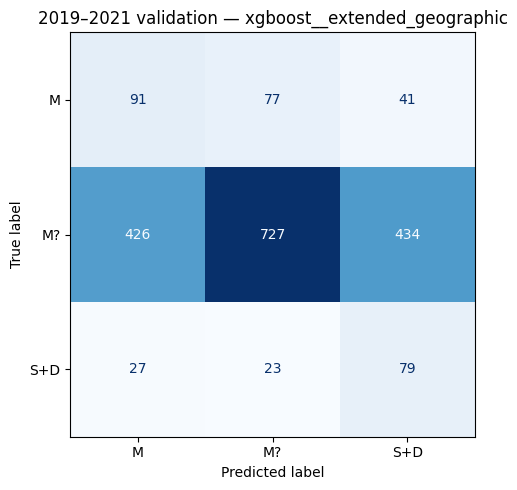

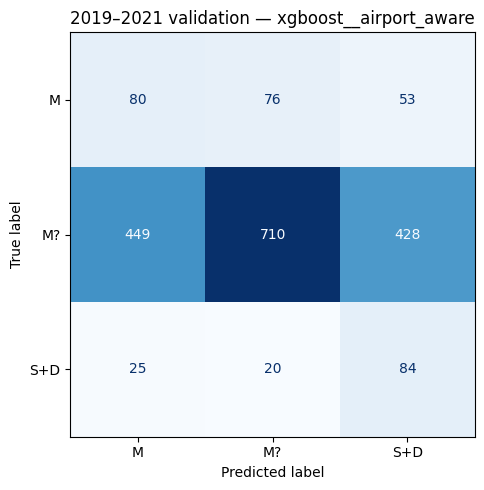

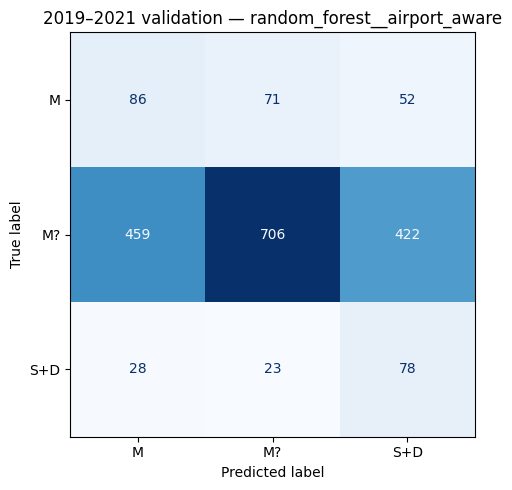

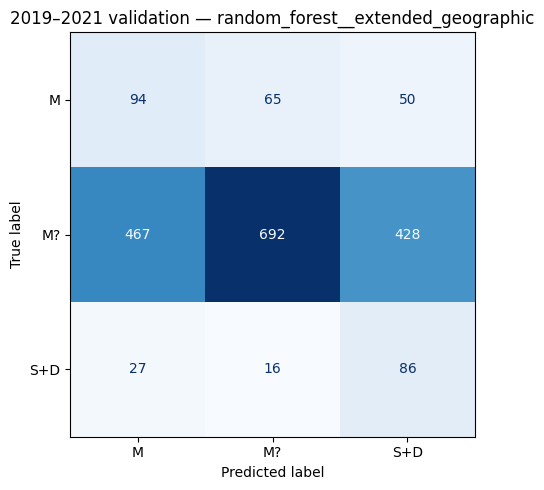

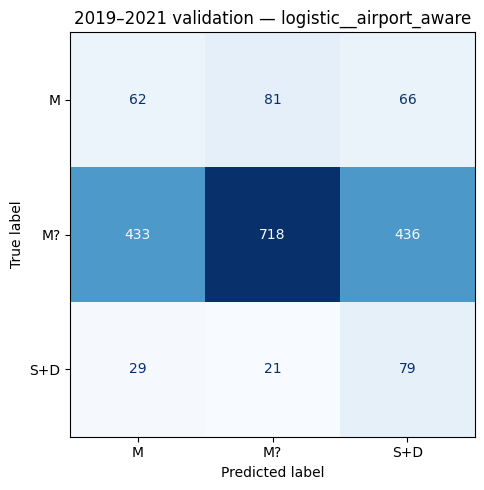

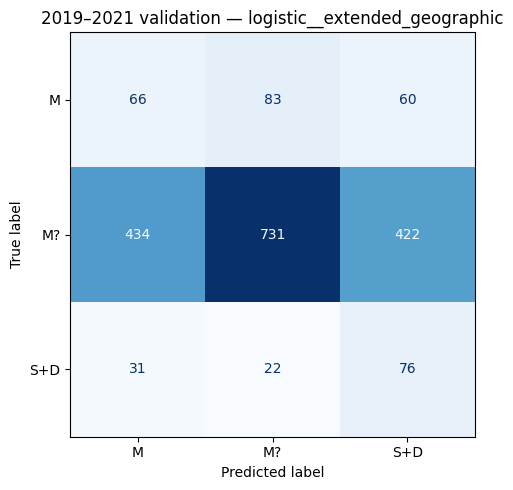

In [22]:
for candidate_name, candidate_info in fitted_candidates.items():
    features = candidate_info["features"]
    prob = candidate_info["pipeline"].predict_proba(
        severity_df.loc[validation_mask, features]
    )
    pred = prob.argmax(axis=1)

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_validation,
        pred,
        labels=np.arange(N_CLASSES),
        display_labels=CLASS_LABELS,
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(f"2019–2021 validation — {candidate_name}")
    plt.tight_layout()
    plt.show()

## 17. Choose the base candidate before calibration

The base candidate is selected using 2019–2021 evidence, with Macro-F1 as the primary score and explicit consideration of:

- `S+D` precision, recall, and F1;
- log loss;
- multiclass Brier score;
- stability relative to chronological CV.

**Do not use 2022–2024 here.**

The automated default below selects the highest validation Macro-F1, breaking ties with `S+D` F1 and then Brier score. If the team overrides that rule for an academically defensible tradeoff, document the override in the markdown immediately below.

In [23]:
selected_validation_row = validation_results.iloc[0]
SELECTED_CANDIDATE = selected_validation_row["candidate"]

print("Automatically selected base candidate:", SELECTED_CANDIDATE)
display(selected_validation_row.to_frame().T.round(4))

# Optional documented override:
# SELECTED_CANDIDATE = "xgboost__airport_aware"

Automatically selected base candidate: xgboost__extended_geographic


,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,log_loss,brier_multiclass,macro_average_precision_ovr,macro_roc_auc_ovr,precision_M,recall_M,f1_M,support_M,precision_M?,recall_M?,f1_M?,support_M?,precision_S+D,recall_S+D,f1_S+D,support_S+D,candidate,model,feature_set,sample_weight_mode
0,0.465974,0.501969,0.39632,0.501969,0.358451,0.538306,1.000488,0.61054,0.415358,0.673313,0.167279,0.435407,0.2417,209,0.879081,0.458097,0.60232,1587,0.142599,0.612403,0.231332,129,xgboost__extended_geographic,xgboost,extended_geographic,balanced


### Base-candidate decision

The extended-geographic XGBoost candidate was retained as the base model because it achieved the highest 2019–2021 validation Macro-F1 (0.358) while also producing the best log loss (1.000) and Brier score (0.611) among the tested candidates. Its `S+D` recall was 0.612, which was lower than the Random Forest's 0.667, but its overall class-balanced performance and probability quality were stronger. The difference was therefore treated as a tradeoff rather than selecting Random Forest solely for severe-class recall. No override of the predefined selection rule was applied.

# 18. Forward calibration experiment inside 2019–2021

Severity probabilities can enter simulation only if their reliability is evaluated.

To preserve temporal order:

- the selected base classifier remains fitted on 1990–2018;
- **2019** is used as the calibration-fitting period;
- **2020–2021** is used to compare raw, sigmoid, and isotonic calibration.

This is analogous to Notebook 06's forward calibration logic.

Calibration is performed one-vs-rest for each class and the resulting class scores are renormalized to sum to one. `M?` remains a nominal class.

The final test remains locked.

In [24]:
calibration_fit_mask = severity_df["INCIDENT_YEAR"].eq(2019)
calibration_eval_mask = severity_df["INCIDENT_YEAR"].between(2020, 2021)

selected_info = fitted_candidates[SELECTED_CANDIDATE]
selected_pipeline = selected_info["pipeline"]
selected_features = selected_info["features"]

X_cal_fit = severity_df.loc[calibration_fit_mask, selected_features]
y_cal_fit = severity_df.loc[calibration_fit_mask, "SEVERITY_TARGET"].to_numpy()

X_cal_eval = severity_df.loc[calibration_eval_mask, selected_features]
y_cal_eval = severity_df.loc[calibration_eval_mask, "SEVERITY_TARGET"].to_numpy()

raw_cal_fit_prob = selected_pipeline.predict_proba(X_cal_fit)
raw_cal_eval_prob = selected_pipeline.predict_proba(X_cal_eval)

print("Calibration-fit rows (2019):", len(y_cal_fit))
print("Calibration-evaluation rows (2020–2021):", len(y_cal_eval))
print("2019 class counts:", np.bincount(y_cal_fit, minlength=N_CLASSES))
print("2020–2021 class counts:", np.bincount(y_cal_eval, minlength=N_CLASSES))

Calibration-fit rows (2019): 765
Calibration-evaluation rows (2020–2021): 1160
2019 class counts: [ 55 654  56]
2020–2021 class counts: [154 933  73]


In [25]:
class OneVsRestProbabilityCalibrator:
    def __init__(self, method="sigmoid"):
        if method not in {"sigmoid", "isotonic"}:
            raise ValueError("method must be 'sigmoid' or 'isotonic'")
        self.method = method
        self.models_ = []

    def fit(self, raw_probabilities, y_true):
        raw_probabilities = np.asarray(raw_probabilities)
        y_true = np.asarray(y_true, dtype=int)
        self.models_ = []

        for class_idx in range(raw_probabilities.shape[1]):
            binary_y = (y_true == class_idx).astype(int)
            x = raw_probabilities[:, class_idx]

            if self.method == "sigmoid":
                model = LogisticRegression(
                    solver="lbfgs",
                    random_state=SEED,
                )
                model.fit(x.reshape(-1, 1), binary_y)
            else:
                model = IsotonicRegression(
                    out_of_bounds="clip",
                    y_min=0.0,
                    y_max=1.0,
                )
                model.fit(x, binary_y)

            self.models_.append(model)

        return self

    def predict_proba(self, raw_probabilities):
        raw_probabilities = np.asarray(raw_probabilities)
        calibrated = np.zeros_like(raw_probabilities, dtype=float)

        for class_idx, model in enumerate(self.models_):
            x = raw_probabilities[:, class_idx]
            if self.method == "sigmoid":
                calibrated[:, class_idx] = model.predict_proba(
                    x.reshape(-1, 1)
                )[:, 1]
            else:
                calibrated[:, class_idx] = model.predict(x)

        calibrated = np.clip(calibrated, 1e-12, None)
        calibrated /= calibrated.sum(axis=1, keepdims=True)
        return calibrated


sigmoid_calibrator = OneVsRestProbabilityCalibrator("sigmoid").fit(
    raw_cal_fit_prob, y_cal_fit
)
isotonic_calibrator = OneVsRestProbabilityCalibrator("isotonic").fit(
    raw_cal_fit_prob, y_cal_fit
)

calibration_methods = {
    "raw": raw_cal_eval_prob,
    "sigmoid": sigmoid_calibrator.predict_proba(raw_cal_eval_prob),
    "isotonic": isotonic_calibrator.predict_proba(raw_cal_eval_prob),
}

calibration_rows = []
for method, prob in calibration_methods.items():
    row = evaluate_multiclass_probabilities(y_cal_eval, prob)
    row["calibration_method"] = method
    calibration_rows.append(row)

calibration_results = (
    pd.DataFrame(calibration_rows)
    .sort_values(
        ["brier_multiclass", "log_loss", "macro_f1"],
        ascending=[True, True, False],
    )
)

display(calibration_results.round(4))
calibration_results.to_csv(
    OUTPUT_DIR / "severity_forward_calibration_comparison.csv",
    index=False,
)

,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,log_loss,brier_multiclass,macro_average_precision_ovr,macro_roc_auc_ovr,precision_M,recall_M,f1_M,support_M,precision_M?,recall_M?,f1_M?,support_M?,precision_S+D,recall_S+D,f1_S+D,support_S+D,calibration_method
1,0.8043,0.3333,0.2681,0.3333,0.2972,0.7171,0.6124,0.3316,0.4043,0.6519,0.0000,0.0000,0.0000,154,0.8043,1.0000,0.8915,933,0.0000,0.0000,0.0000,73,sigmoid
2,0.8026,0.3422,0.6439,0.3422,0.3178,0.7229,0.8932,0.3326,0.4129,0.6624,1.0000,0.0195,0.0382,154,0.8068,0.9936,0.8905,933,0.1250,0.0137,0.0247,73,isotonic
0,0.4560,0.4929,0.3972,0.4929,0.3591,0.5242,1.0094,0.6164,0.4034,0.6563,0.2105,0.4416,0.2851,154,0.8583,0.4480,0.5887,933,0.1229,0.5890,0.2033,73,raw


### Calibration decision rule

The calibration method is selected primarily by **multiclass Brier score and log loss** because this stage concerns probability reliability, not threshold classification.

Calibration is **not forced**. If raw probabilities are better than both calibration methods, the raw system is retained.

Macro-F1 is shown to confirm that calibration has not introduced unexpected argmax-classification behavior, but it is not the primary calibration criterion.

In [26]:
SELECTED_CALIBRATION_METHOD = calibration_results.iloc[0]["calibration_method"]
print("Selected calibration method:", SELECTED_CALIBRATION_METHOD)

Selected calibration method: sigmoid


### Calibration interpretation

Forward calibration on 2020–2021 produced a substantial improvement in aggregate probability error but also exposed a major limitation caused by the changed class distribution. Raw XGBoost probabilities had a multiclass Brier score of 0.616 and log loss 1.009. Sigmoid calibration improved these to 0.332 and 0.612, respectively, and was therefore selected over isotonic calibration, which produced a similar Brier score (0.333) but worse log loss (0.893). However, the sigmoid-calibrated classifier predicted only the dominant `M?` class at the default argmax decision: `M?` recall became 1.00, while recall for both `M` and `S+D` fell to 0. Thus, the improvement in Brier score and log loss reflects better alignment with the highly dominant recent `M?` prevalence, not successful discrimination among all severity classes. Calibration therefore improves aggregate probability fit but does not resolve the underlying multiclass generalization problem.

## 19. Class-wise calibration plots

These plots treat each severity class as one-vs-rest and compare predicted probability bins with observed class frequency.

They are diagnostic plots; they do not imply that `M`, `M?`, and `S+D` form an ordinal sequence.

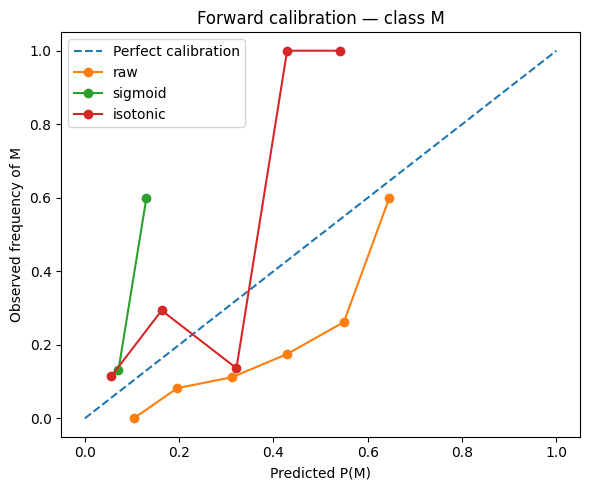

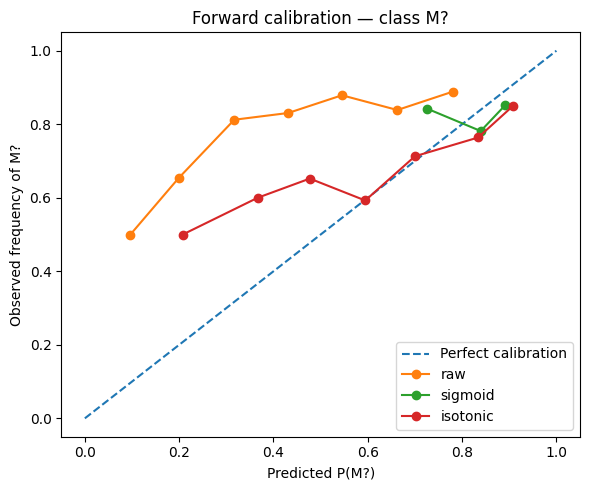

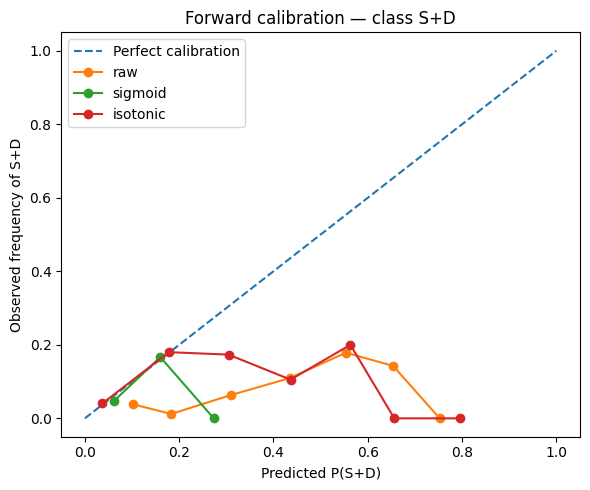

In [27]:
def plot_classwise_calibration(y_true, probability_dict, n_bins=8):
    y_true = np.asarray(y_true)

    for class_idx, label in enumerate(CLASS_LABELS):
        plt.figure(figsize=(6, 5))
        plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

        binary_y = (y_true == class_idx).astype(int)

        for method, probs in probability_dict.items():
            p = probs[:, class_idx]
            bins = np.linspace(0, 1, n_bins + 1)
            ids = np.digitize(p, bins[1:-1], right=True)

            mean_pred = []
            observed = []
            for b in range(n_bins):
                m = ids == b
                if m.sum() == 0:
                    continue
                mean_pred.append(p[m].mean())
                observed.append(binary_y[m].mean())

            plt.plot(mean_pred, observed, marker="o", label=method)

        plt.xlabel(f"Predicted P({label})")
        plt.ylabel(f"Observed frequency of {label}")
        plt.title(f"Forward calibration — class {label}")
        plt.legend()
        plt.tight_layout()
        plt.show()

plot_classwise_calibration(y_cal_eval, calibration_methods)

# 20. Lock the final severity probability system

At this point, all decisions must be fixed **before opening 2022–2024**:

1. target definition: `M`, `M?`, `S+D`;
2. feature set;
3. model family;
4. hyperparameters;
5. class/sample weighting choice;
6. calibration method.

The selected base model remains trained on 1990–2018, and the calibrator is refitted using all 2019–2021 probabilities. This mirrors the role of the calibration period in Notebook 06.

In [28]:
# Refit the selected calibrator using all 2019–2021 validation data.
X_validation_selected = severity_df.loc[validation_mask, selected_features]
y_validation_all = severity_df.loc[validation_mask, "SEVERITY_TARGET"].to_numpy()
raw_validation_all_prob = selected_pipeline.predict_proba(X_validation_selected)

if SELECTED_CALIBRATION_METHOD == "raw":
    final_calibrator = None
elif SELECTED_CALIBRATION_METHOD == "sigmoid":
    final_calibrator = OneVsRestProbabilityCalibrator("sigmoid").fit(
        raw_validation_all_prob, y_validation_all
    )
elif SELECTED_CALIBRATION_METHOD == "isotonic":
    final_calibrator = OneVsRestProbabilityCalibrator("isotonic").fit(
        raw_validation_all_prob, y_validation_all
    )
else:
    raise ValueError("Unknown calibration method.")

locked_configuration = {
    "target_classes": CLASS_LABELS,
    "destroyed_merge": "D merged into S for modelling only -> S+D",
    "m_question_mark": "retained as independent undetermined-level class",
    "selected_candidate": SELECTED_CANDIDATE,
    "selected_features": selected_features,
    "sample_weight_mode": selected_info["sample_weight_mode"],
    "selected_params": selected_info["selected_params"],
    "selected_calibration_method": SELECTED_CALIBRATION_METHOD,
    "train_period": "1990-2018",
    "calibration_period": "2019-2021",
    "final_test_period": "2022-2024",
    "seed": SEED,
}

with open(
    OUTPUT_DIR / "severity_locked_configuration.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(locked_configuration, f, indent=2, default=str)

display(pd.Series(locked_configuration, name="locked_value"))

target_classes                                                      [M, M?, S+D]
destroyed_merge                        D merged into S for modelling only -> S+D
m_question_mark                 retained as independent undetermined-level class
selected_candidate                                  xgboost__extended_geographic
selected_features              [SEASON, MONTH_SIN, MONTH_COS, WILDLIFE_TYPE, ...
sample_weight_mode                                                      balanced
selected_params                {'model__colsample_bytree': 0.8, 'model__learn...
selected_calibration_method                                              sigmoid
train_period                                                           1990-2018
calibration_period                                                     2019-2021
final_test_period                                                      2022-2024
seed                                                                          42
Name: locked_value, dtype: o

# 21. FINAL TEST UNLOCK — 2022–2024

**Do not run this section until every cell above has completed and the locked configuration has been saved.**

The final test is used once to answer whether the severity component generalizes sufficiently for downstream use.

The decision must consider:

- overall Macro-F1;
- `S+D` precision, recall, and F1;
- confusion matrix;
- log loss and Brier score;
- calibration behavior;
- performance by test year;
- stability of the `M?` class;
- support limitations.

No hyperparameters, feature sets, or calibration methods may be changed in response to this final-test result.

In [29]:
X_test = severity_df.loc[test_mask, selected_features]
y_test = severity_df.loc[test_mask, "SEVERITY_TARGET"].to_numpy()

raw_test_prob = selected_pipeline.predict_proba(X_test)

if final_calibrator is None:
    final_test_prob = raw_test_prob
else:
    final_test_prob = final_calibrator.predict_proba(raw_test_prob)

final_test_pred = final_test_prob.argmax(axis=1)

final_test_metrics = evaluate_multiclass_probabilities(
    y_test,
    final_test_prob,
    final_test_pred,
)

display(pd.DataFrame([final_test_metrics]).round(4))

pd.DataFrame([final_test_metrics]).to_csv(
    OUTPUT_DIR / "severity_final_test_metrics.csv",
    index=False,
)

test_predictions = pd.DataFrame({
    "INDEX_NR": severity_df.loc[test_mask, "INDEX_NR"].to_numpy(),
    "INCIDENT_YEAR": severity_df.loc[test_mask, "INCIDENT_YEAR"].to_numpy(),
    "observed_severity": severity_df.loc[test_mask, "SEVERITY_MODEL"].to_numpy(),
    "predicted_severity": [INT_TO_LABEL[i] for i in final_test_pred],
})

for i, label in enumerate(CLASS_LABELS):
    test_predictions[f"prob_{label}"] = final_test_prob[:, i]

test_predictions.to_csv(
    OUTPUT_DIR / "severity_final_test_predictions.csv",
    index=False,
)

,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,log_loss,brier_multiclass,macro_average_precision_ovr,macro_roc_auc_ovr,precision_M,recall_M,f1_M,support_M,precision_M?,recall_M?,f1_M?,support_M?,precision_S+D,recall_S+D,f1_S+D,support_S+D
0,0.8121,0.3333,0.2707,0.3333,0.2988,0.7279,0.5757,0.3137,0.4043,0.6551,0.0,0.0,0.0,270,0.8121,1.0,0.8963,1824,0.0,0.0,0.0,152


### Final-test interpretation

On the locked 2022–2024 final test, the calibrated severity system achieved 81.2% accuracy, but this value is misleading because the model predicted `M?` for every incident. Balanced accuracy was only 0.333 and Macro-F1 only 0.299. For Minor damage, precision, recall, and F1 were all 0. For `M?`, precision was 0.812, recall 1.000, and F1 0.896. For `S+D`, precision, recall, and F1 were all 0, meaning that all 152 substantial/destroyed incidents were missed. There were no `S+D` false positives because the model never predicted that class. Macro average precision remained 0.404 and macro ROC-AUC 0.655, indicating that some ranking signal remains in the underlying probability scores even though the calibrated argmax predictions collapse to the dominant class. Log loss was 0.576 and multiclass Brier score 0.314, but these apparently favorable probability-error scores are heavily influenced by the 81.2% prevalence of `M?`. Compared with validation, the final test therefore confirms that the current calibrated three-class system does not provide usable class-level severity discrimination.

## 22. Final-test confusion matrix

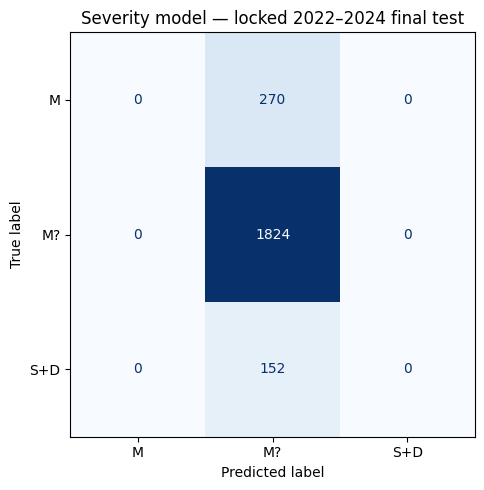

In [30]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_test_pred,
    labels=np.arange(N_CLASSES),
    display_labels=CLASS_LABELS,
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title("Severity model — locked 2022–2024 final test")
plt.tight_layout()
plt.show()

## 23. Final-test performance by year

An aggregate 2022–2024 score can hide drift. Metrics are therefore reported separately for each final-test year. These are descriptive diagnostics only and cannot be used to retune the model.

In [31]:
year_rows = []

test_positions = severity_df.loc[test_mask, ["INCIDENT_YEAR"]].reset_index(drop=True)

for year in sorted(test_positions["INCIDENT_YEAR"].unique()):
    m = test_positions["INCIDENT_YEAR"].eq(year).to_numpy()

    metrics = evaluate_multiclass_probabilities(
        y_test[m],
        final_test_prob[m],
        final_test_pred[m],
    )
    metrics["year"] = int(year)
    metrics["rows"] = int(m.sum())
    year_rows.append(metrics)

year_metrics = pd.DataFrame(year_rows)
display(year_metrics.round(4))
year_metrics.to_csv(
    OUTPUT_DIR / "severity_final_test_metrics_by_year.csv",
    index=False,
)

,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,log_loss,brier_multiclass,macro_average_precision_ovr,macro_roc_auc_ovr,precision_M,recall_M,f1_M,support_M,precision_M?,recall_M?,f1_M?,support_M?,precision_S+D,recall_S+D,f1_S+D,support_S+D,year,rows
0,0.7934,0.3333,0.2645,0.3333,0.2949,0.7021,0.6157,0.3420,0.3973,0.6386,0.0,0.0,0.0,102,0.7934,1.0,0.8848,557,0.0,0.0,0.0,43,2022,702
1,0.8086,0.3333,0.2695,0.3333,0.2981,0.7230,0.5832,0.3160,0.4383,0.6787,0.0,0.0,0.0,74,0.8086,1.0,0.8942,583,0.0,0.0,0.0,64,2023,721
2,0.8311,0.3333,0.2770,0.3333,0.3026,0.7544,0.5350,0.2875,0.3952,0.6526,0.0,0.0,0.0,94,0.8311,1.0,0.9078,684,0.0,0.0,0.0,45,2024,823


### Year-by-year interpretation

The same failure pattern is present in each individual final-test year. In 2022, 2023, and 2024, balanced accuracy remained 0.333 and recall/F1 for both `M` and `S+D` remained 0, while `M?` recall was 1.00 in every year. Macro-F1 was correspondingly stable but low at approximately 0.295, 0.298, and 0.303. The number of S+D cases was 43 in 2022, 64 in 2023, and 45 in 2024, and every one was missed by the calibrated classifier. Brier score improved numerically from 0.342 in 2022 to 0.288 in 2024, while log loss declined from 0.616 to 0.535, but this should not be interpreted as improved severity discrimination because the predicted class remained `M?` for all observations. The year-specific evidence therefore indicates a persistent structural failure rather than an isolated poor year.

# 24. Known-severity sensitivity analysis: `M` versus `S+D`

`M?` creates a scientifically important complication: it represents an **unknown level of damage**, not a physical point on a severity continuum.

The main three-class model appropriately preserves this category. As a sensitivity analysis, this section asks a narrower question:

> **Among damaged incidents whose severity level was actually determined, can scenario-eligible predictors distinguish Minor from Substantial/Destroyed damage?**

This analysis:

- excludes `M?`;
- does not replace the main three-class model;
- must be described as a selected known-severity subset;
- is useful for distinguishing physical-severity predictability from predictability of reporting completeness.

To avoid doubling the full tuning burden, the sensitivity analysis uses the **already selected model family, feature set, and structural hyperparameters**. It is therefore diagnostic rather than a second independent model search.

In [32]:
known_df = severity_df.loc[
    severity_df["SEVERITY_MODEL"].isin(["M", "S+D"])
].copy()

known_df["KNOWN_SEVERITY_TARGET"] = (
    known_df["SEVERITY_MODEL"].eq("S+D").astype(int)
)

known_train = known_df["INCIDENT_YEAR"].between(1990, 2018)
known_validation = known_df["INCIDENT_YEAR"].between(2019, 2021)
known_test = known_df["INCIDENT_YEAR"].between(2022, 2024)

known_summary = []
for split_name, mask in [
    ("train", known_train),
    ("validation", known_validation),
    ("test", known_test),
]:
    subset = known_df.loc[mask]
    known_summary.append({
        "split": split_name,
        "rows": len(subset),
        "minor": int((subset["KNOWN_SEVERITY_TARGET"] == 0).sum()),
        "severe_S_plus_D": int((subset["KNOWN_SEVERITY_TARGET"] == 1).sum()),
        "severe_rate": subset["KNOWN_SEVERITY_TARGET"].mean(),
    })

display(pd.DataFrame(known_summary).round(4))

,split,rows,minor,severe_S_plus_D,severe_rate
0,train,12330,8178,4152,0.3367
1,validation,338,209,129,0.3817
2,test,422,270,152,0.3602


### Known-severity sensitivity interpretation

The known-severity subset contains enough observations to support a possible follow-up binary sensitivity analysis: 12,330 training cases (8,178 `M`, 4,152 `S+D`), 338 validation cases (209 `M`, 129 `S+D`), and 422 final-test cases (270 `M`, 152 `S+D`). The severe rate is relatively stable across these subsets at approximately 33.7%, 38.2%, and 36.0%, unlike the extreme temporal shift observed when `M?` is retained. This suggests that a binary `M` versus `S+D` formulation may be worth evaluating if the project wishes to simplify severity modelling. However, the current notebook does not fit or validate that sensitivity model, so these counts alone are insufficient to justify using a simplified severity model in simulation.

## 24.1 - Known-severity binary target

Following the three-class decision-gate result and the professor's recommendation, a simplified severity formulation is evaluated as a secondary sensitivity model.

This analysis excludes `M?` because it represents **undetermined severity**, rather than an observed physical severity level. Among incidents for which severity was determined, the target is:

- `0` — Minor (`M`)
- `1` — Severe (`S+D`)

The severe category retains the earlier modelling decision to combine Substantial and Destroyed incidents because Destroyed remains too sparse for reliable independent estimation.

The model therefore estimates:

**P(S+D | reported strike, aircraft damage occurred, severity was determined, scenario)**

This is narrower than the original three-class problem and must not be interpreted as the probability that every damaged strike is severe, because historically undetermined (`M?`) reports are excluded from this conditional population.

The chronological split remains unchanged so the simplified formulation can be evaluated under the same temporal discipline as the primary models.

In [9]:
known_df = severity_df.loc[
    severity_df["SEVERITY_MODEL"].isin(["M", "S+D"])
].copy()

known_df["KNOWN_SEVERITY_TARGET"] = (
    known_df["SEVERITY_MODEL"].eq("S+D").astype(int)
)

known_train_mask = known_df["INCIDENT_YEAR"].between(1990, 2018)
known_validation_mask = known_df["INCIDENT_YEAR"].between(2019, 2021)
known_test_mask = known_df["INCIDENT_YEAR"].between(2022, 2024)

known_split_rows = []

for split_name, mask in [
    ("train_1990_2018", known_train_mask),
    ("validation_2019_2021", known_validation_mask),
    ("test_2022_2024_LOCKED", known_test_mask),
]:
    subset = known_df.loc[mask]
    positives = int(subset["KNOWN_SEVERITY_TARGET"].sum())
    negatives = int(len(subset) - positives)

    known_split_rows.append({
        "split": split_name,
        "rows": len(subset),
        "minor_M": negatives,
        "severe_S_plus_D": positives,
        "severe_rate": positives / len(subset) if len(subset) else np.nan,
    })

known_split_summary = pd.DataFrame(known_split_rows)

display(known_split_summary.round(4))

known_split_summary.to_csv(
    OUTPUT_DIR / "known_severity_binary_split_summary.csv",
    index=False,
)

,split,rows,minor_M,severe_S_plus_D,severe_rate
0,train_1990_2018,12330,8178,4152,0.3367
1,validation_2019_2021,338,209,129,0.3817
2,test_2022_2024_LOCKED,422,270,152,0.3602


### Interpretation — known-severity population

After excluding `M?`, the known-severity population contains **12,330 training incidents**, **338 validation incidents**, and **422 final-test incidents**. The `S+D` rate is **33.7%** in training, **38.2%** in validation, and **36.0%** in the locked test period.

This distribution is substantially more stable over time than the original three-class severity target, where `M?` increased from approximately 26% of training observations to more than 80% of later observations. The simplified target therefore removes the category responsible for the largest temporal reporting shift while retaining the physically interpretable distinction between Minor and Substantial/Destroyed damage.

This does not mean that `M?` observations are unimportant. They are excluded because the severity level was not determined, so the resulting model is conditional on severity having been observed.

## 24.2 — Expanding chronological cross-validation

The simplified binary model uses the same five expanding chronological folds used elsewhere in the project. Hyperparameters are selected using only pre-2019 data.

Because this is again a binary outcome, **PR-AUC for the severe (`S+D`) class is used as the primary tuning metric**, while precision, recall, F1, balanced accuracy, ROC-AUC, Brier score, and log loss are retained as companion metrics.

PR-AUC is appropriate here because the modelling question specifically requires useful discrimination of the positive severe class rather than performance dominated by the more common Minor observations.

In [10]:
KNOWN_CV_FOLDS = [
    {
        "fold": 1,
        "train_years": range(1990, 2004),
        "validation_years": range(2004, 2007),
    },
    {
        "fold": 2,
        "train_years": range(1990, 2007),
        "validation_years": range(2007, 2010),
    },
    {
        "fold": 3,
        "train_years": range(1990, 2010),
        "validation_years": range(2010, 2013),
    },
    {
        "fold": 4,
        "train_years": range(1990, 2013),
        "validation_years": range(2013, 2016),
    },
    {
        "fold": 5,
        "train_years": range(1990, 2016),
        "validation_years": range(2016, 2019),
    },
]

known_cv_rows = []

for spec in KNOWN_CV_FOLDS:
    fold_train = known_df.loc[
        known_df["INCIDENT_YEAR"].isin(spec["train_years"])
    ]
    fold_val = known_df.loc[
        known_df["INCIDENT_YEAR"].isin(spec["validation_years"])
    ]

    known_cv_rows.append({
        "fold": spec["fold"],
        "train_start": min(spec["train_years"]),
        "train_end": max(spec["train_years"]),
        "validation_start": min(spec["validation_years"]),
        "validation_end": max(spec["validation_years"]),
        "train_rows": len(fold_train),
        "train_severe": int(fold_train["KNOWN_SEVERITY_TARGET"].sum()),
        "train_severe_rate": fold_train["KNOWN_SEVERITY_TARGET"].mean(),
        "validation_rows": len(fold_val),
        "validation_severe": int(fold_val["KNOWN_SEVERITY_TARGET"].sum()),
        "validation_severe_rate": fold_val["KNOWN_SEVERITY_TARGET"].mean(),
    })

known_cv_summary = pd.DataFrame(known_cv_rows)

display(known_cv_summary.round(4))

known_cv_summary.to_csv(
    OUTPUT_DIR / "known_severity_binary_cv_design.csv",
    index=False,
)

assert (known_cv_summary["train_severe"] > 0).all()
assert (known_cv_summary["validation_severe"] > 0).all()

,fold,train_start,train_end,validation_start,validation_end,train_rows,train_severe,train_severe_rate,validation_rows,validation_severe,validation_severe_rate
0,1,1990,2003,2004,2006,6249,2150,0.3441,1381,464,0.3360
1,2,1990,2006,2007,2009,7630,2614,0.3426,1205,362,0.3004
2,3,1990,2009,2010,2012,8835,2976,0.3368,1496,482,0.3222
3,4,1990,2012,2013,2015,10331,3458,0.3347,1397,517,0.3701
4,5,1990,2015,2016,2018,11728,3975,0.3389,602,177,0.2940


### Interpretation — chronological CV support

All five chronological validation folds contain substantial numbers of both Minor and `S+D` incidents, with severe-event rates ranging from approximately **29% to 37%**. Unlike the original three-class severity formulation, no fold is dominated by a changing undetermined category.

The expanding-window design therefore provides sufficient support to tune the simplified model while preserving temporal order. Hyperparameters continue to be selected only from pre-2019 observations.

## 24.3 — Binary candidate models and hyperparameter search

The same candidate families are retained for comparability:

1. Logistic Regression
2. Random Forest
3. XGBoost

The hyperparameter ranges remain close to those used in the earlier modelling stages. Class weighting is again treated as a hyperparameter rather than imposed automatically.

For XGBoost, balanced per-observation sample weights are tested instead of assuming imbalance correction is required. The severe class represents roughly one third of known-severity observations, so imbalance is substantially less extreme than in some earlier project targets.

In [11]:
def make_known_severity_pipeline(model_name, features):
    if model_name == "logistic":
        model = LogisticRegression(
            max_iter=3000,
            solver="lbfgs",
            penalty="l2",
            C=1.0,
            class_weight=None,
            random_state=SEED,
        )
        prep = make_preprocessor(features, scale_numeric=True)

    elif model_name == "random_forest":
        model = RandomForestClassifier(
            n_estimators=300,
            class_weight=None,
            n_jobs=-1,
            random_state=SEED,
        )
        prep = make_preprocessor(features, scale_numeric=False)

    elif model_name == "xgboost":
        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            n_jobs=-1,
            random_state=SEED,
        )
        prep = make_preprocessor(features, scale_numeric=False)

    else:
        raise ValueError(f"Unknown model: {model_name}")

    return Pipeline([
        ("preprocess", prep),
        ("model", model),
    ])


KNOWN_LOGISTIC_GRID = [
    {
        "model__solver": ["saga"],
        "model__penalty": ["l1", "l2"],
        "model__C": [0.1, 1.0, 5.0],
        "model__class_weight": [None, "balanced"],
    },
    {
        "model__solver": ["lbfgs"],
        "model__penalty": ["l2"],
        "model__C": [0.1, 1.0, 5.0],
        "model__class_weight": [None, "balanced"],
    },
]

KNOWN_RF_GRID = {
    "model__n_estimators": [250, 400],
    "model__max_depth": [12, None],
    "model__min_samples_split": [2, 10],
    "model__min_samples_leaf": [2, 10],
    "model__max_features": ["sqrt", 0.5],
    "model__class_weight": [None, "balanced_subsample"],
}

KNOWN_XGB_GRID = {
    "model__n_estimators": [300, 600],
    "model__max_depth": [3, 6],
    "model__learning_rate": [0.03, 0.08],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 5],
    "model__reg_lambda": [1.0, 5.0],
    "sample_weight_mode": ["none", "balanced"],
}

KNOWN_PARAMETER_GRIDS = {
    "logistic": KNOWN_LOGISTIC_GRID,
    "random_forest": KNOWN_RF_GRID,
    "xgboost": KNOWN_XGB_GRID,
}

known_candidate_counts = []

for model_name, grid in KNOWN_PARAMETER_GRIDS.items():
    n_settings = len(list(ParameterGrid(grid)))

    known_candidate_counts.append({
        "model": model_name,
        "settings_per_feature_set": n_settings,
        "feature_sets": len(FEATURE_SETS),
        "cv_folds": len(KNOWN_CV_FOLDS),
        "total_model_fits": (
            n_settings
            * len(FEATURE_SETS)
            * len(KNOWN_CV_FOLDS)
        ),
    })

known_candidate_count_table = pd.DataFrame(known_candidate_counts)

display(known_candidate_count_table)

print(
    "Total binary severity chronological-CV fits:",
    int(known_candidate_count_table["total_model_fits"].sum()),
)

,model,settings_per_feature_set,feature_sets,cv_folds,total_model_fits
0,logistic,18,2,5,180
1,random_forest,64,2,5,640
2,xgboost,256,2,5,2560


Total binary severity chronological-CV fits: 3380


### Search scope

The binary severity experiment evaluates **3,380 chronological-CV model fits** across Logistic Regression, Random Forest, and XGBoost, two approved feature sets, and five temporal folds. This retains a search depth comparable to the earlier modelling stages while remaining computationally practical because the known-severity population is much smaller than the original binary-damage dataset.

## 24.4 - Binary metrics and CV helpers

In [12]:
def binary_brier_score(y_true, probabilities):
    y_true = np.asarray(y_true, dtype=float)
    probabilities = np.asarray(probabilities, dtype=float)
    return float(np.mean((probabilities - y_true) ** 2))


def evaluate_binary_severity(
    y_true,
    probabilities,
    threshold=0.50,
):
    y_true = np.asarray(y_true, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)

    predicted = (probabilities >= threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        predicted,
        average="binary",
        pos_label=1,
        zero_division=0,
    )

    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predicted),
        "balanced_accuracy": balanced_accuracy_score(y_true, predicted),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "pr_auc": average_precision_score(y_true, probabilities),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "brier": binary_brier_score(y_true, probabilities),
        "log_loss": log_loss(y_true, probabilities, labels=[0, 1]),
    }


def fit_known_pipeline(
    pipeline,
    X,
    y,
    sample_weight_mode="none",
):
    fit_kwargs = {}

    if sample_weight_mode == "balanced":
        fit_kwargs["model__sample_weight"] = compute_sample_weight(
            class_weight="balanced",
            y=y,
        )

    elif sample_weight_mode != "none":
        raise ValueError(
            f"Unknown sample_weight_mode: {sample_weight_mode}"
        )

    return pipeline.fit(X, y, **fit_kwargs)


def evaluate_known_setting_cv(
    model_name,
    features,
    params,
):
    params = dict(params)
    sample_weight_mode = params.pop(
        "sample_weight_mode",
        "none",
    )

    fold_rows = []

    for spec in KNOWN_CV_FOLDS:
        fold_train_mask = known_df["INCIDENT_YEAR"].isin(
            spec["train_years"]
        )
        fold_val_mask = known_df["INCIDENT_YEAR"].isin(
            spec["validation_years"]
        )

        X_fold_train = known_df.loc[
            fold_train_mask, features
        ]
        y_fold_train = known_df.loc[
            fold_train_mask, "KNOWN_SEVERITY_TARGET"
        ]

        X_fold_val = known_df.loc[
            fold_val_mask, features
        ]
        y_fold_val = known_df.loc[
            fold_val_mask, "KNOWN_SEVERITY_TARGET"
        ]

        pipeline = make_known_severity_pipeline(
            model_name,
            features,
        )
        pipeline.set_params(**params)

        pipeline = fit_known_pipeline(
            pipeline,
            X_fold_train,
            y_fold_train,
            sample_weight_mode=sample_weight_mode,
        )

        probabilities = pipeline.predict_proba(
            X_fold_val
        )[:, 1]

        metrics = evaluate_binary_severity(
            y_fold_val,
            probabilities,
            threshold=0.50,
        )

        metrics.update({
            "fold": spec["fold"],
            "sample_weight_mode": sample_weight_mode,
        })

        fold_rows.append(metrics)

    return pd.DataFrame(fold_rows)


def summarize_known_cv(
    model_name,
    feature_set_name,
    params,
    fold_results,
):
    row = {
        "model": model_name,
        "feature_set": feature_set_name,
        "params": json.dumps(
            params,
            sort_keys=True,
            default=str,
        ),
    }

    for metric in [
        "pr_auc",
        "precision",
        "recall",
        "f1",
        "balanced_accuracy",
        "roc_auc",
        "brier",
        "log_loss",
    ]:
        row[f"mean_{metric}"] = fold_results[metric].mean()
        row[f"std_{metric}"] = fold_results[metric].std(ddof=1)

    return row

## 24.5 - Baseline model

In [13]:
known_baseline = DummyClassifier(
    strategy="prior",
    random_state=SEED,
)

X_known_train_baseline = known_df.loc[
    known_train_mask,
    EXTENDED_FEATURES,
]
y_known_train = known_df.loc[
    known_train_mask,
    "KNOWN_SEVERITY_TARGET",
]

X_known_validation_baseline = known_df.loc[
    known_validation_mask,
    EXTENDED_FEATURES,
]
y_known_validation = known_df.loc[
    known_validation_mask,
    "KNOWN_SEVERITY_TARGET",
]

known_baseline.fit(
    X_known_train_baseline,
    y_known_train,
)

known_baseline_prob = known_baseline.predict_proba(
    X_known_validation_baseline
)[:, 1]

known_baseline_metrics = evaluate_binary_severity(
    y_known_validation,
    known_baseline_prob,
)

display(
    pd.DataFrame([known_baseline_metrics]).round(4)
)

,threshold,accuracy,balanced_accuracy,precision,recall,f1,pr_auc,roc_auc,brier,log_loss
0,0.5,0.6183,0.5,0.0,0.0,0.0,0.3817,0.5,0.238,0.6693


### Baseline interpretation

The prior-probability baseline effectively classifies all validation incidents as Minor at the default 0.50 threshold. It therefore obtains **61.8% accuracy**, but severe-class precision, recall, and F1 are all **0**, while balanced accuracy and ROC-AUC remain at **0.50**.

Its PR-AUC of **0.382** corresponds closely to the severe-class prevalence in the validation data and provides the no-skill probability-ranking reference. A useful severity model should therefore improve materially on this PR-AUC while also achieving non-zero severe-class recall and acceptable probability error.

## 24.6 - Hyperparameter tuning

In [14]:
known_tuning_rows = []

for model_name, grid in KNOWN_PARAMETER_GRIDS.items():

    print("\\nTuning:", model_name)

    for feature_set_name, features in FEATURE_SETS.items():

        for params in ParameterGrid(grid):

            fold_results = evaluate_known_setting_cv(
                model_name,
                features,
                params,
            )

            known_tuning_rows.append(
                summarize_known_cv(
                    model_name,
                    feature_set_name,
                    params,
                    fold_results,
                )
            )

known_tuning_results = (
    pd.DataFrame(known_tuning_rows)
    .sort_values(
        [
            "mean_pr_auc",
            "mean_f1",
            "mean_brier",
        ],
        ascending=[False, False, True],
    )
)

known_tuning_results.to_csv(
    OUTPUT_DIR
    / "known_severity_binary_chronological_cv_results.csv",
    index=False,
)

display(
    known_tuning_results.head(40).round(4)
)

\nTuning: logistic
\nTuning: random_forest
\nTuning: xgboost


,model,feature_set,params,mean_pr_auc,std_pr_auc,mean_precision,std_precision,mean_recall,std_recall,mean_f1,std_f1,mean_balanced_accuracy,std_balanced_accuracy,mean_roc_auc,std_roc_auc,mean_brier,std_brier,mean_log_loss,std_log_loss
172,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.5455,0.0313,0.5916,0.0399,0.3254,0.0829,0.4147,0.0751,0.6091,0.0284,0.7208,0.0165,0.1910,0.0110,0.5637,0.0265
317,xgboost,extended_geographic,"{""model__colsample_bytree"": 1.0, ""model__learn...",0.5453,0.0315,0.4969,0.0365,0.6186,0.0382,0.5497,0.0198,0.6589,0.0200,0.7180,0.0161,0.2096,0.0066,0.6070,0.0148
300,xgboost,extended_geographic,"{""model__colsample_bytree"": 1.0, ""model__learn...",0.5448,0.0298,0.5943,0.0377,0.3294,0.0808,0.4189,0.0702,0.6110,0.0278,0.7199,0.0167,0.1912,0.0111,0.5642,0.0268
316,xgboost,extended_geographic,"{""model__colsample_bytree"": 1.0, ""model__learn...",0.5446,0.0296,0.5832,0.0532,0.3295,0.0868,0.4155,0.0775,0.6087,0.0294,0.7178,0.0176,0.1917,0.0112,0.5655,0.0267
188,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.5446,0.0294,0.5807,0.0471,0.3243,0.0820,0.4111,0.0738,0.6063,0.0273,0.7182,0.0183,0.1915,0.0113,0.5651,0.0272
228,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.5443,0.0277,0.5840,0.0493,0.3465,0.0785,0.4306,0.0661,0.6143,0.0275,0.7185,0.0167,0.1915,0.0116,0.5652,0.0283
305,xgboost,extended_geographic,"{""model__colsample_bytree"": 1.0, ""model__learn...",0.5438,0.0355,0.4969,0.0368,0.6209,0.0351,0.5505,0.0171,0.6595,0.0138,0.7183,0.0140,0.2095,0.0059,0.6068,0.0132
301,xgboost,extended_geographic,"{""model__colsample_bytree"": 1.0, ""model__learn...",0.5438,0.0333,0.4964,0.0356,0.6121,0.0377,0.5468,0.0188,0.6569,0.0176,0.7187,0.0149,0.2092,0.0061,0.6061,0.0137
192,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.5438,0.0324,0.5889,0.0326,0.3232,0.0836,0.4116,0.0731,0.6074,0.0270,0.7190,0.0165,0.1914,0.0108,0.5647,0.0256
236,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.5438,0.0251,0.5785,0.0413,0.3641,0.0724,0.4426,0.0546,0.6181,0.0228,0.7149,0.0198,0.1929,0.0126,0.5698,0.0318


In [15]:
known_best_by_model_feature = (
    known_tuning_results
    .sort_values(
        [
            "mean_pr_auc",
            "mean_f1",
            "mean_brier",
        ],
        ascending=[False, False, True],
    )
    .groupby(
        ["model", "feature_set"],
        as_index=False,
    )
    .first()
    .sort_values(
        ["mean_pr_auc", "mean_f1"],
        ascending=False,
    )
)

display(
    known_best_by_model_feature.round(4)
)

known_best_by_model_feature.to_csv(
    OUTPUT_DIR
    / "known_severity_binary_selected_cv_settings.csv",
    index=False,
)

,model,feature_set,params,mean_pr_auc,std_pr_auc,mean_precision,std_precision,mean_recall,std_recall,mean_f1,std_f1,mean_balanced_accuracy,std_balanced_accuracy,mean_roc_auc,std_roc_auc,mean_brier,std_brier,mean_log_loss,std_log_loss
5,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.5455,0.0313,0.5916,0.0399,0.3254,0.0829,0.4147,0.0751,0.6091,0.0284,0.7208,0.0165,0.1910,0.0110,0.5637,0.0265
4,xgboost,airport_aware,"{""model__colsample_bytree"": 1.0, ""model__learn...",0.5426,0.0350,0.5835,0.0705,0.3242,0.0858,0.4124,0.0822,0.6078,0.0331,0.7182,0.0157,0.1915,0.0105,0.5649,0.0250
3,random_forest,extended_geographic,"{""model__class_weight"": null, ""model__max_dept...",0.5275,0.0337,0.5972,0.0392,0.2611,0.0653,0.3597,0.0662,0.5886,0.0234,0.7145,0.0138,0.1938,0.0106,0.5713,0.0235
2,random_forest,airport_aware,"{""model__class_weight"": null, ""model__max_dept...",0.5274,0.0340,0.5946,0.0478,0.2314,0.0719,0.3286,0.0794,0.5785,0.0268,0.7145,0.0155,0.1943,0.0107,0.5727,0.0238
1,logistic,extended_geographic,"{""model__C"": 0.1, ""model__class_weight"": ""bala...",0.5141,0.0276,0.4815,0.0384,0.6061,0.0321,0.5348,0.0107,0.6461,0.0110,0.6922,0.0125,0.2191,0.0053,0.6292,0.0113
0,logistic,airport_aware,"{""model__C"": 0.1, ""model__class_weight"": ""bala...",0.5117,0.0286,0.4773,0.0338,0.5967,0.0365,0.5286,0.0080,0.6413,0.0109,0.6910,0.0134,0.2196,0.0053,0.6302,0.0117


### Hyperparameter-tuning interpretation

XGBoost achieved the strongest chronological-CV probability discrimination. Its best extended-geographic configuration obtained mean **PR-AUC = 0.546 ± 0.031** and **ROC-AUC = 0.721 ± 0.017**, compared with approximately **0.528 PR-AUC** for Random Forest and **0.514** for Logistic Regression.

The selected XGBoost configuration used a relatively shallow maximum depth of 3, learning rate 0.03, 600 estimators, 0.8 column and row subsampling, and no class/sample weighting. This is notable because weighting was available in the search but was not required for the best probability-ranking performance in the simplified target.

At the default 0.50 threshold, the best XGBoost configuration had relatively high severe-class precision but lower recall. Logistic Regression achieved greater recall and F1 through balanced class weighting, but its PR-AUC, ROC-AUC, Brier score, and log loss were weaker. Because the downstream objective is probability-based simulation, PR-AUC and probability quality remain more important than choosing the model solely from its default-threshold F1.

## 24.7 - Refit and validate on 2019-2021

In [16]:
known_fitted_candidates = {}
known_validation_rows = []

for _, selected in known_best_by_model_feature.iterrows():

    model_name = selected["model"]
    feature_set_name = selected["feature_set"]
    features = FEATURE_SETS[feature_set_name]

    params = json.loads(selected["params"])

    sample_weight_mode = params.pop(
        "sample_weight_mode",
        "none",
    )

    pipeline = make_known_severity_pipeline(
        model_name,
        features,
    )
    pipeline.set_params(**params)

    X_train_known = known_df.loc[
        known_train_mask,
        features,
    ]
    X_val_known = known_df.loc[
        known_validation_mask,
        features,
    ]

    pipeline = fit_known_pipeline(
        pipeline,
        X_train_known,
        y_known_train,
        sample_weight_mode=sample_weight_mode,
    )

    probabilities = pipeline.predict_proba(
        X_val_known
    )[:, 1]

    metrics = evaluate_binary_severity(
        y_known_validation,
        probabilities,
        threshold=0.50,
    )

    candidate_name = (
        f"{model_name}__{feature_set_name}"
    )

    metrics.update({
        "candidate": candidate_name,
        "model": model_name,
        "feature_set": feature_set_name,
        "sample_weight_mode": sample_weight_mode,
    })

    known_validation_rows.append(metrics)

    known_fitted_candidates[candidate_name] = {
        "pipeline": pipeline,
        "features": features,
        "sample_weight_mode": sample_weight_mode,
        "params": params,
        "validation_probabilities": probabilities,
    }


known_validation_results = (
    pd.DataFrame(known_validation_rows)
    .sort_values(
        ["pr_auc", "f1", "brier"],
        ascending=[False, False, True],
    )
)

display(
    known_validation_results.round(4)
)

known_validation_results.to_csv(
    OUTPUT_DIR
    / "known_severity_binary_validation_metrics.csv",
    index=False,
)

KNOWN_SELECTED_CANDIDATE = (
    known_validation_results.iloc[0]["candidate"]
)

print(
    "Selected known-severity candidate:",
    KNOWN_SELECTED_CANDIDATE,
)

,threshold,accuracy,balanced_accuracy,precision,recall,f1,pr_auc,roc_auc,brier,log_loss,candidate,model,feature_set,sample_weight_mode
1,0.5,0.6923,0.6221,0.7119,0.3256,0.4468,0.6664,0.7659,0.1930,0.5701,xgboost__airport_aware,xgboost,airport_aware,none
0,0.5,0.6982,0.6358,0.6957,0.3721,0.4848,0.6593,0.7681,0.1927,0.5694,xgboost__extended_geographic,xgboost,extended_geographic,none
2,0.5,0.6598,0.5706,0.6944,0.1938,0.3030,0.6571,0.7729,0.1983,0.5796,random_forest__extended_geographic,random_forest,extended_geographic,none
3,0.5,0.6479,0.5521,0.6786,0.1473,0.2420,0.6466,0.7722,0.2002,0.5843,random_forest__airport_aware,random_forest,airport_aware,none
4,0.5,0.6509,0.6509,0.5350,0.6512,0.5874,0.5528,0.6964,0.2243,0.6430,logistic__extended_geographic,logistic,extended_geographic,none
5,0.5,0.6420,0.6423,0.5253,0.6434,0.5784,0.5483,0.6937,0.2254,0.6461,logistic__airport_aware,logistic,airport_aware,none


Selected known-severity candidate: xgboost__airport_aware


### Validation interpretation and candidate selection

Performance improves rather than deteriorates when the CV-selected candidates are evaluated on the independent **2019–2021** period. The airport-aware XGBoost candidate achieves the highest validation **PR-AUC of 0.666**, substantially above the baseline value of 0.382. Its ROC-AUC is **0.766**, Brier score **0.193**, and log loss **0.570**.

At the default 0.50 threshold, severe-class precision is relatively strong (**0.712**) but recall is only **0.326**, producing F1 **0.447**. This indicates that the probability ranking contains useful information, but 0.50 is too conservative if the classification objective requires stronger identification of severe incidents.

The airport-aware XGBoost candidate is therefore retained because it provides the strongest validation PR-AUC. The extended-geographic XGBoost performs very similarly, indicating that the choice is not based on a large performance gap.

## 24.8 - Confusion matrix + threshold exploration

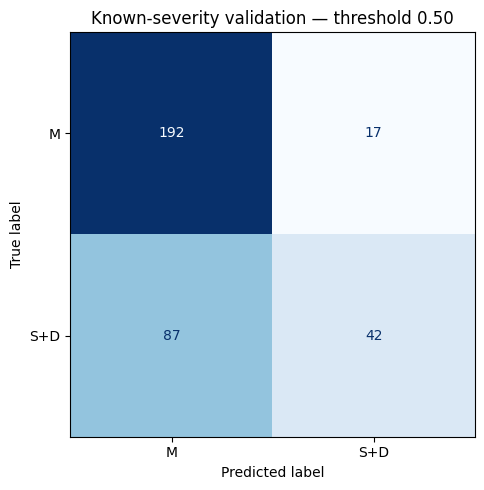

,threshold,precision,recall,f1,balanced_accuracy
0,0.10,0.3918,0.9690,0.5580,0.5204
1,0.15,0.4261,0.9612,0.5905,0.5811
2,0.20,0.4577,0.9225,0.6118,0.6239
3,0.25,0.5093,0.8527,0.6377,0.6728
4,0.30,0.5587,0.7752,0.6494,0.6986
5,0.35,0.6174,0.7132,0.6619,0.7202
6,0.40,0.6667,0.6202,0.6426,0.7144
7,0.45,0.6705,0.4574,0.5438,0.6593
8,0.50,0.7119,0.3256,0.4468,0.6221
9,0.55,0.7632,0.2248,0.3473,0.5909


In [18]:
known_selected_info = known_fitted_candidates[
    KNOWN_SELECTED_CANDIDATE
]

known_selected_pipeline = known_selected_info[
    "pipeline"
]
known_selected_features = known_selected_info[
    "features"
]

known_val_prob = known_selected_info[
    "validation_probabilities"
]


# Default 0.50 confusion matrix
known_val_pred_050 = (
    known_val_prob >= 0.50
).astype(int)

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_known_validation,
    known_val_pred_050,
    display_labels=["M", "S+D"],
    cmap="Blues",
    colorbar=False,
    ax=ax,
)

ax.set_title(
    "Known-severity validation — threshold 0.50"
)

plt.tight_layout()
plt.show()


# Threshold exploration
threshold_rows = []

for threshold in np.arange(
    0.10,
    0.91,
    0.05,
):
    metrics = evaluate_binary_severity(
        y_known_validation,
        known_val_prob,
        threshold=float(threshold),
    )

    threshold_rows.append(metrics)

known_threshold_results = pd.DataFrame(
    threshold_rows
)

display(
    known_threshold_results[
        [
            "threshold",
            "precision",
            "recall",
            "f1",
            "balanced_accuracy",
        ]
    ].round(4)
)

known_threshold_results.to_csv(
    OUTPUT_DIR
    / "known_severity_binary_threshold_exploration.csv",
    index=False,
)

### Threshold-behaviour interpretation

Threshold exploration shows that the relatively low severe-class recall at the default 0.50 threshold was primarily a decision-threshold issue rather than evidence that the model lacked severe-event ranking ability.

On the 2019–2021 validation data, a threshold of **0.35** provided the strongest observed F1 (**0.662**) and balanced accuracy (**0.720**), with precision **0.617** and recall **0.713**. Lower thresholds increased recall further but introduced more false-positive severe classifications, while higher thresholds improved precision at the cost of missing more severe cases.

The 0.35 threshold was therefore locked before opening the final test. It is retained only for hard-classification reporting and confusion matrices; probability-based downstream simulation uses the continuous model probabilities directly.

In [22]:
KNOWN_SELECTED_THRESHOLD = 0.35

print(
    "Locked known-severity classification threshold:",
    KNOWN_SELECTED_THRESHOLD,
)

Locked known-severity classification threshold: 0.35


## 24.9 - Forward calibration

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression


known_cal_fit_mask = known_df[
    "INCIDENT_YEAR"
].eq(2019)

known_cal_eval_mask = known_df[
    "INCIDENT_YEAR"
].between(2020, 2021)

X_known_cal_fit = known_df.loc[
    known_cal_fit_mask,
    known_selected_features,
]
y_known_cal_fit = known_df.loc[
    known_cal_fit_mask,
    "KNOWN_SEVERITY_TARGET",
].to_numpy()

X_known_cal_eval = known_df.loc[
    known_cal_eval_mask,
    known_selected_features,
]
y_known_cal_eval = known_df.loc[
    known_cal_eval_mask,
    "KNOWN_SEVERITY_TARGET",
].to_numpy()

raw_known_cal_fit_prob = (
    known_selected_pipeline.predict_proba(
        X_known_cal_fit
    )[:, 1]
)

raw_known_cal_eval_prob = (
    known_selected_pipeline.predict_proba(
        X_known_cal_eval
    )[:, 1]
)


# Sigmoid / Platt scaling
known_sigmoid = LogisticRegression(
    solver="lbfgs",
    random_state=SEED,
)

known_sigmoid.fit(
    raw_known_cal_fit_prob.reshape(-1, 1),
    y_known_cal_fit,
)

known_sigmoid_eval_prob = (
    known_sigmoid.predict_proba(
        raw_known_cal_eval_prob.reshape(-1, 1)
    )[:, 1]
)


# Isotonic
known_isotonic = IsotonicRegression(
    out_of_bounds="clip",
    y_min=0.0,
    y_max=1.0,
)

known_isotonic.fit(
    raw_known_cal_fit_prob,
    y_known_cal_fit,
)

known_isotonic_eval_prob = (
    known_isotonic.predict(
        raw_known_cal_eval_prob
    )
)


known_calibration_probabilities = {
    "raw": raw_known_cal_eval_prob,
    "sigmoid": known_sigmoid_eval_prob,
    "isotonic": known_isotonic_eval_prob,
}

known_calibration_rows = []

for method, probabilities in (
    known_calibration_probabilities.items()
):

    metrics = evaluate_binary_severity(
        y_known_cal_eval,
        probabilities,
        threshold=0.50,
    )

    metrics["calibration_method"] = method

    known_calibration_rows.append(metrics)


known_calibration_results = (
    pd.DataFrame(known_calibration_rows)
    .sort_values(
        ["brier", "log_loss"],
        ascending=[True, True],
    )
)

display(
    known_calibration_results.round(4)
)

known_calibration_results.to_csv(
    OUTPUT_DIR
    / "known_severity_binary_calibration.csv",
    index=False,
)

KNOWN_SELECTED_CALIBRATION = (
    known_calibration_results.iloc[0][
        "calibration_method"
    ]
)

print(
    "Selected calibration:",
    KNOWN_SELECTED_CALIBRATION,
)

,threshold,accuracy,balanced_accuracy,precision,recall,f1,pr_auc,roc_auc,brier,log_loss,calibration_method
0,0.5,0.7357,0.6287,0.6857,0.3288,0.4444,0.6194,0.7586,0.1798,0.5434,raw
2,0.5,0.7225,0.7162,0.5543,0.6986,0.6182,0.5716,0.7502,0.1985,1.4507,isotonic
1,0.5,0.7181,0.6985,0.5529,0.6438,0.5949,0.6194,0.7586,0.2132,0.6183,sigmoid


Selected calibration: raw


### Calibration interpretation

Neither sigmoid nor isotonic calibration improves the selected model's probability quality on the forward 2020–2021 evaluation period. The **raw XGBoost probabilities** achieve the lowest Brier score (**0.180**) and log loss (**0.543**), compared with Brier scores of approximately 0.213 for sigmoid and 0.199 for isotonic calibration.

Raw probabilities are therefore retained. Calibration is not forced simply because it is available; the purpose of the calibration stage is to improve probability reliability, and the evidence shows that post-hoc calibration would make the probability estimates worse in this case.

This differs importantly from the original three-class formulation, where calibration interacted strongly with the dominant `M?` category. The simplified known-severity formulation does not exhibit that same probability collapse.

## 24.10 - Locked 2022-2024 final test

> **Do not change anything afterward based on test results.**

In [20]:
X_known_validation_all = known_df.loc[
    known_validation_mask,
    known_selected_features,
]

y_known_validation_all = known_df.loc[
    known_validation_mask,
    "KNOWN_SEVERITY_TARGET",
].to_numpy()

raw_known_validation_all_prob = (
    known_selected_pipeline.predict_proba(
        X_known_validation_all
    )[:, 1]
)


if KNOWN_SELECTED_CALIBRATION == "raw":

    known_final_calibrator = None

elif KNOWN_SELECTED_CALIBRATION == "sigmoid":

    known_final_calibrator = LogisticRegression(
        solver="lbfgs",
        random_state=SEED,
    )

    known_final_calibrator.fit(
        raw_known_validation_all_prob.reshape(
            -1, 1
        ),
        y_known_validation_all,
    )

elif KNOWN_SELECTED_CALIBRATION == "isotonic":

    known_final_calibrator = IsotonicRegression(
        out_of_bounds="clip",
        y_min=0.0,
        y_max=1.0,
    )

    known_final_calibrator.fit(
        raw_known_validation_all_prob,
        y_known_validation_all,
    )

else:
    raise ValueError(
        "Unknown calibration method."
    )

,threshold,accuracy,balanced_accuracy,precision,recall,f1,pr_auc,roc_auc,brier,log_loss
0,0.35,0.7417,0.7277,0.6319,0.6776,0.654,0.6485,0.7865,0.1844,0.5468


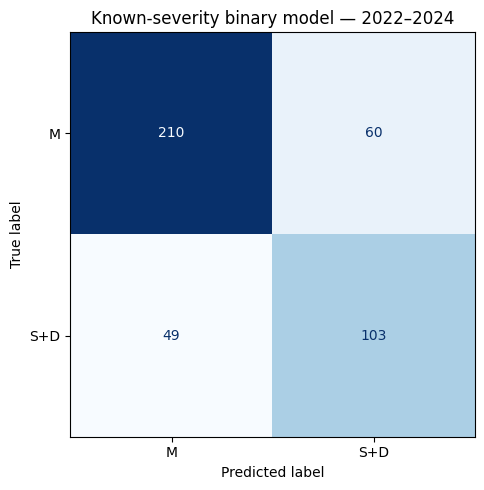

In [23]:
X_known_test = known_df.loc[
    known_test_mask,
    known_selected_features,
]

y_known_test = known_df.loc[
    known_test_mask,
    "KNOWN_SEVERITY_TARGET",
].to_numpy()

raw_known_test_prob = (
    known_selected_pipeline.predict_proba(
        X_known_test
    )[:, 1]
)


if known_final_calibrator is None:

    known_final_test_prob = (
        raw_known_test_prob
    )

elif KNOWN_SELECTED_CALIBRATION == "sigmoid":

    known_final_test_prob = (
        known_final_calibrator.predict_proba(
            raw_known_test_prob.reshape(
                -1, 1
            )
        )[:, 1]
    )

else:

    known_final_test_prob = (
        known_final_calibrator.predict(
            raw_known_test_prob
        )
    )


known_final_test_metrics = (
    evaluate_binary_severity(
        y_known_test,
        known_final_test_prob,
        threshold=KNOWN_SELECTED_THRESHOLD,
    )
)

display(
    pd.DataFrame(
        [known_final_test_metrics]
    ).round(4)
)

pd.DataFrame(
    [known_final_test_metrics]
).to_csv(
    OUTPUT_DIR
    / "known_severity_binary_final_test_metrics.csv",
    index=False,
)


known_final_test_pred = (
    known_final_test_prob >= KNOWN_SELECTED_THRESHOLD
).astype(int)

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_known_test,
    known_final_test_pred,
    display_labels=["M", "S+D"],
    cmap="Blues",
    colorbar=False,
    ax=ax,
)

ax.set_title(
    "Known-severity binary model — 2022–2024"
)

plt.tight_layout()
plt.show()

### Final-test interpretation

The locked 2022–2024 test confirms that the simplified known-severity model retains useful discrimination, probability quality, and classification performance outside the tuning and validation periods.

At the probability level, final-test **PR-AUC is 0.649** and ROC-AUC is **0.787**, while Brier score is **0.184** and log loss is **0.547**. These values remain close to the 2019–2021 validation results (PR-AUC 0.666, ROC-AUC 0.766, Brier 0.193, log loss 0.570), indicating that the simplified model does not exhibit the temporal collapse observed in the original three-class formulation.

Using the **0.35 classification threshold selected exclusively from the validation period**, the final test correctly identifies **103 of 152 `S+D` incidents**, while 49 severe incidents are missed. Among Minor incidents, 210 of 270 are correctly classified and 60 are incorrectly classified as severe. This corresponds to severe-class precision of approximately **0.632**, recall **0.678**, F1 **0.654**, and balanced accuracy **0.728**.

These results are also highly consistent with the validation performance at the same threshold (precision 0.617, recall 0.713, F1 0.662, balanced accuracy 0.720). The similarity between validation and final-test behaviour provides evidence that the selected threshold generalizes rather than merely fitting the validation period.

The threshold is used only for classification summaries and confusion matrices. Downstream Monte Carlo simulation will use the model's continuous predicted probability of `S+D`, not the 0.35 hard-classification cutoff.

# 25. Decision gate: RETAIN, SIMPLIFY, or DROP

There is no universal metric threshold that automatically proves severity is suitable for Monte Carlo simulation. The decision is evidence-based and should be conservative because downstream simulation would repeatedly sample these probabilities.

Use the following gate.

### RETAIN

Retain the three-class severity model only if:

- it materially exceeds the majority baseline;
- Macro-F1 is useful and reasonably stable from CV → validation → final test;
- `S+D` is not effectively ignored;
- class-specific precision/recall are interpretable with their support counts;
- Brier score/log loss and calibration plots show usable probability behavior;
- no severe temporal collapse appears in 2022–2024.

### SIMPLIFY

Simplify if the three-class model is weak primarily because `M?` cannot be predicted reliably, while a defensible narrower representation has materially better support. Possible downstream simplification must be documented explicitly; it must **not** silently reinterpret `M?` as Minor.

### DROP

Drop severity from simulation if:

- the final system is only marginally above baseline;
- `S+D` performance is inadequate or unstable;
- probabilities remain poorly calibrated;
- temporal generalization is weak;
- or the model would create more confidence than the data support.

Dropping severity does **not** mean Substantial/Destroyed damage is unimportant. It means the available FAA reporting data and approved scenario predictors are insufficient to estimate its conditional probability reliably enough for this project's simulation.

The primary Notebook 06 damage-probability model remains valid independently of this secondary decision.

In [25]:
THREE_CLASS_SEVERITY_DECISION = "DROP"

SEVERITY_DECISION = "SIMPLIFY"

ALLOWED_DECISIONS = {"PENDING", "RETAIN", "SIMPLIFY", "DROP"}
assert SEVERITY_DECISION in ALLOWED_DECISIONS

print(
    "Three-class severity decision:",
    THREE_CLASS_SEVERITY_DECISION,
)

print(
    "Overall severity decision:",
    SEVERITY_DECISION,
)

Three-class severity decision: DROP
Overall severity decision: SIMPLIFY


### Final severity decision

**Overall decision:** `SIMPLIFY`  
**Original three-class formulation:** `DROP`

The original three-class severity formulation (`M`, `M?`, `S+D`) remains rejected. Its performance deteriorated under later-year validation because the `M?` category underwent a substantial temporal reporting shift, and the calibrated final system ultimately failed to identify any `S+D` incidents.

Following the sensitivity analysis, severity was therefore reformulated among incidents for which severity was actually determined. The simplified target distinguishes **Minor (`M`)** from **Substantial/Destroyed (`S+D`)**, while excluding `M?` rather than reinterpreting it as a physical severity class.

This known-severity binary formulation demonstrates substantially stronger and more temporally stable performance. The selected XGBoost model achieved validation **PR-AUC = 0.666** and final-test **PR-AUC = 0.649**, with final ROC-AUC **0.787**, Brier score **0.184**, and log loss **0.547**. These probability metrics remain close across validation and the locked 2022–2024 test period.

Using the **0.35 threshold selected only from validation data**, final-test severe-class precision is approximately **0.632**, recall **0.678**, and F1 **0.654**, with balanced accuracy **0.728**. The final confusion matrix correctly identifies **103 of 152 `S+D` incidents**, while 49 are missed and 60 Minor incidents are classified as severe. These results are also consistent with validation performance at the same threshold.

Post-hoc sigmoid and isotonic calibration were tested, but neither improved Brier score or log loss. The **raw XGBoost probabilities** are therefore retained for downstream probability use.

The severity component is consequently assigned a **SIMPLIFY** decision rather than being dropped entirely. Notebook 10 may use the simplified known-severity probability model only under the following interpretation:

**P(S+D | reported wildlife strike, aircraft damage occurred, severity was determined, scenario)**

This model must not be presented as estimating severity for incidents whose severity would historically remain undetermined (`M?`).

## 26. Save the approved simplified severity artifact

The original three-class severity model did not pass its decision gate and is not exported for downstream use.

However, the known-severity binary formulation passed the simplified decision gate. Because the overall decision is **SIMPLIFY**, this section saves the approved `M` versus `S+D` probability system to `models/final/` together with the conditioning statement, selected candidate, calibration decision, and feature list.

A separate `severity_decision.json` artifact records the decision for downstream notebooks. Notebook 10 must inspect this file before loading severity and must respect the narrower interpretation of the simplified model:

**P(S+D | reported strike, damage occurred, severity was determined, scenario)**

In [27]:
final_model_exported = False
final_model_path = None

if SEVERITY_DECISION == "SIMPLIFY":

    known_severity_artifact = {
        "base_pipeline": known_selected_pipeline,
        "features": known_selected_features,
        "classification_threshold": KNOWN_SELECTED_THRESHOLD,

        "target_definition": {
            "0": "M",
            "1": "S+D",
        },

        "conditioning": (
            "Conditional on reported strike, "
            "aircraft damage occurring, and "
            "severity being determined."
        ),

        "excluded_severity_category": "M?",

        "selected_candidate": (
            KNOWN_SELECTED_CANDIDATE
        ),

        "calibration_method": (
            KNOWN_SELECTED_CALIBRATION
        ),

        "calibrator": known_final_calibrator,

        "train_period": "1990-2018",
        "calibration_period": "2019-2021",
        "final_test_period": "2022-2024",

        "seed": SEED,
        "decision": "SIMPLIFY",
    }

    final_model_path = (
        FINAL_MODEL_DIR
        / "final_known_severity_probability_system.joblib"
    )

    joblib.dump(
        known_severity_artifact,
        final_model_path,
    )

    final_model_exported = True

    print(
        "Saved simplified severity model:",
        final_model_path,
    )

else:

    print(
        "No final severity model exported because "
        f"the decision is {SEVERITY_DECISION}."
    )


decision_record = {
    "decision": SEVERITY_DECISION,

    "three_class_decision": "DROP",

    "known_severity_binary_tested": True,

    "known_severity_candidate": (
        KNOWN_SELECTED_CANDIDATE
    ),

    "known_severity_calibration_method": (
        KNOWN_SELECTED_CALIBRATION
    ),
    
    "known_severity_classification_threshold": (
        KNOWN_SELECTED_THRESHOLD
    ),

    "known_severity_conditioning": (
        "P(S+D | reported strike, damage occurred, "
        "severity was determined, scenario)"
    ),

    "excluded_category": "M?",

    "final_model_exported": (
        final_model_exported
    ),

    "final_model_path": (
        str(final_model_path)
        if final_model_path is not None
        else None
    ),
}


decision_path = (
    OUTPUT_DIR
    / "severity_decision.json"
)

with open(
    decision_path,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        decision_record,
        f,
        indent=2,
    )


print(
    "Saved decision artifact:",
    decision_path,
)

Saved simplified severity model: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\models\final\final_known_severity_probability_system.joblib
Saved decision artifact: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\outputs\07_severity_modeling\severity_decision.json


## 27. Output inventory and hand-off

Expected persistent outputs:

### `outputs/07_severity_modeling/`

- `severity_raw_class_counts.csv`
- `severity_split_class_counts.csv`
- `severity_chronological_cv_design.csv`
- `logistic_severity_chronological_cv_results.csv`
- `random_forest_severity_chronological_cv_results.csv`
- `xgboost_severity_chronological_cv_results.csv`
- `severity_cv_selected_settings.csv`
- `severity_2019_2021_candidate_metrics.csv`
- `severity_2019_2021_candidate_probabilities.csv`
- `severity_forward_calibration_comparison.csv`
- `severity_locked_configuration.json`
- `severity_final_test_metrics.csv`
- `severity_final_test_predictions.csv`
- `severity_final_test_metrics_by_year.csv`
- `known_severity_binary_split_summary.csv`
- `known_severity_binary_cv_design.csv`
- `known_severity_binary_chronological_cv_results.csv`
- `known_severity_binary_selected_cv_settings.csv`
- `known_severity_binary_validation_metrics.csv`
- `known_severity_binary_threshold_exploration.csv`
- `known_severity_binary_calibration.csv`
- `known_severity_binary_final_test_metrics.csv`
- `severity_decision.json`

### `models/candidates/`

Candidate artifacts from the original three-class severity experiment may be present from the earlier modelling stage. The simplified known-severity experiment is evaluated in-memory and only its approved final model is exported.

### `models/final/`

`final_known_severity_probability_system.joblib` — exported when the overall severity decision is `SIMPLIFY`.

### Downstream rule

Notebook 10 must inspect `severity_decision.json` before loading a severity model.

- `SIMPLIFY` → use only `final_known_severity_probability_system.joblib`, with the interpretation that severity is conditional on damage occurring **and severity being determined**.
- `DROP` → do not use severity in Monte Carlo.

## 28. Limitations

- This model is conditional on a **reported wildlife strike that already has `INDICATED_DAMAGE = 1`**.
- `M?` is a reporting-uncertainty class and not an ordered physical severity level.
- Combining `D` with `S` is a statistical-support compromise and does not erase their aviation-safety distinction.
- The FAA database is observational and subject to reporting-practice and completeness changes.
- Historical associations and model predictions are not causal effects.
- Class weighting changes the training objective and may affect probability calibration; this is why weighting is tuned and calibration is tested separately.
- Airport and category support can change over time.
- Very small subgroup counts can make apparently large metric differences unstable.
- A successful classification model is not automatically a trustworthy probability model; calibration evidence is required for simulation.
- The simplified binary model excludes `M?` observations and therefore estimates severity only among incidents where severity was historically determined. Its probabilities must not be interpreted as unconditional severity probabilities for all damaged strikes.
- The 0.35 threshold is used only for classification summaries. Monte Carlo simulation should consume the continuous `S+D` probability rather than thresholded class labels.

## 29. References

**Domain definitions**

- Federal Aviation Administration. *Wildlife Strike Database field/data dictionary*, damage-level definitions based on the ICAO IBIS Manual (Fourth Edition, 2001). The project copy is retained as the original data dictionary.

**Imbalanced classification**

- He, H., & Garcia, E. A. (2009). Learning from Imbalanced Data. *IEEE Transactions on Knowledge and Data Engineering, 21*(9), 1263–1284.

**Machine-learning implementations**

- Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.
- Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*.

**Probability/calibration caution**

- van den Goorbergh, R., van Smeden, M., Timmerman, D., & Van Calster, B. Research on class-imbalance corrections in risk-prediction models, showing that imbalance interventions can alter calibration. This is used here to justify validating weighted and unweighted candidates rather than assuming weighting is always beneficial.

### Project continuity

This notebook should be interpreted together with:

- Notebook 02 — canonical cleaning, feature eligibility, and split definitions;
- Notebook 05 — candidate-model and chronological hyperparameter-tuning design;
- Notebook 06 — probability calibration and final-test discipline;
- Notebook 10 — Monte Carlo simulation, which may consume severity only after this notebook's decision gate.